# Chittagong Bangla Emotion Classification


**Architecture (Strategy 1 — Recommended)**
```
chittagong_bangla_speech   → char-BiLSTM  → proj 256 ─┐
chittagong_banglish_speech → char-BiLSTM  → proj 256 ─┤ concat(1024) → head → 23 emotions
bangla_speech              → BanglaBERT CLS → proj 256 ─┤
english_speech             → RoBERTa-base CLS → proj 256 ─┘
```



## 1 · Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Mon May 11 08:45:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn \
    matplotlib seaborn pandas numpy shap lime statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2 · Imports & Reproducibility

In [ ]:
import os, json, random, warnings, textwrap
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict

# ── sklearn ────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, brier_score_loss,
    precision_recall_fscore_support,
)
from sklearn.calibration import calibration_curve

# ── torch ──────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import GradScaler, autocast

# ── HuggingFace ────────────────────────────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup,
)

# ── Explainability ─────────────────────────────────────────────────────────────
import shap
from lime.lime_text import LimeTextExplainer

# ── Significance ───────────────────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
})
PAL20 = sns.color_palette("tab20", 20)
PAL10 = sns.color_palette("tab10", 10)

# ── Seed ───────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED);
np.random.seed(SEED)
torch.manual_seed(SEED);
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_STR = device.type
print("Device :", device)
if device.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    print("VRAM   :", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 3 · Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/NLP/CTG_Sentiment"
SAVE_DIR  = "/content/drive/MyDrive/NLP/ctg_fusion_emnlp"
FIG_DIR   = "/content/drive/MyDrive/NLP/ctg_fusion_figures"

TRAIN_CSV = f"{DATA_DIR}/train_uniform50.csv"
VAL_CSV   = f"{DATA_DIR}/val_uniform50.csv"
TEST_CSV  = f"{DATA_DIR}/test_uniform50.csv"

# ── Column names ───────────────────────────────────────────────────────────────
COL_CTG_BANGLA   = "chittagong_bangla_speech"    # Bengali script  → char-BiLSTM
COL_CTG_BANGLISH = "chittagong_banglish_speech"  # Latin script    → char-BiLSTM
COL_STD_BANGLA   = "bangla_speech"               # Std Bangla      → BanglaBERT
COL_ENGLISH      = "english_speech"              # English         → RoBERTa-base
COL_LABEL        = "emotions"
ALL_TEXT_COLS    = [COL_CTG_BANGLA, COL_CTG_BANGLISH, COL_STD_BANGLA, COL_ENGLISH]

# ── Pretrained models ──────────────────────────────────────────────────────────

BANGLABERT_NAME  = "csebuetnlp/banglabert"
ROBERTA_NAME     = "roberta-base"

# ── Architecture ───────────────────────────────────────────────────────────────
PROJ_DIM       = 256       # each branch → 256
FUSED_DIM      = PROJ_DIM * 4   # 1024
CHAR_EMBED_DIM = 128       # was 64
CHAR_HIDDEN    = 256       # was 128 → BiLSTM output = 512

# ── Training ───────────────────────────────────────────────────────────────────
EPOCHS          = 15
TRANSFORMER_LR  = 2e-5
LSTM_LR         = 5e-4
HEAD_LR         = 1e-3
WEIGHT_DECAY    = 0.10     # OVERFIT FIX: was 0.05; stronger L2 penalty for the fully-trainable char BiLSTMs
WARMUP_RATIO    = 0.12
BATCH_SIZE      = 16
ACCUM_STEPS     = 2
EARLY_STOP      = 2        # OVERFIT FIX: was 4; gap hits ~9× in just 4 extra epochs after best ep — no benefit waiting
LABEL_SMOOTHING = 0.15     # OVERFIT FIX: was 0.10; higher smoothing discourages overconfident train predictions
FOCAL_GAMMA     = 1.5      # OVERFIT FIX: was 2.0; gamma=2.0 down-weights easy examples so aggressively
                              # that train loss → ~0 (pure memorisation); 1.5 keeps the curriculum effect
                              # without allowing near-zero train loss
MAX_SEQ_LEN     = 96
AUGMENT_PROB    = 0.65     # OVERFIT FIX: was 0.50; more augmented samples reduce char-BiLSTM memorisation

# ── Transformer layer freezing (FIX 6: freeze bottom 8 layers to reduce overfit)
FREEZE_BOTTOM_LAYERS = 9   # OVERFIT FIX: was 8; freezing one more layer reduces fine-tuned params

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)
print("Config OK  |  FUSED_DIM:", FUSED_DIM)
print(f"BanglaBERT : {BANGLABERT_NAME}")
print(f"Char hidden: {CHAR_HIDDEN}  Char embed: {CHAR_EMBED_DIM}")


Config OK  |  FUSED_DIM: 1024
BanglaBERT : csebuetnlp/banglabert
Char hidden: 256  Char embed: 128


## 4 · Data Loading & Exploration

In [ ]:
def load_clean(path):
    df = pd.read_csv(path)
    required = ALL_TEXT_COLS + [COL_LABEL]
    for col in required:
        df = df.dropna(subset=[col])
        df = df[df[col].astype(str).str.strip().astype(bool)]
    return df.reset_index(drop=True)

train_df = load_clean(TRAIN_CSV)
val_df   = load_clean(VAL_CSV)
test_df  = load_clean(TEST_CSV)
all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Splits: train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")
print(f"Classes: {train_df[COL_LABEL].nunique()}")
print("\nSample:")
print(train_df[ALL_TEXT_COLS + [COL_LABEL]].iloc[0].to_dict())

Splits: train=805  val=172  test=173
Classes: 23

Sample:
{'chittagong_bangla_speech': 'তোয়ার ফোন্না ফরিয়েরে লাবহান কি যদি তুই যারে ভালোবাসো তারেই ন ফো', 'chittagong_banglish_speech': 'toyar fonna foriyere labhan ki jodi tui jare valobaso tarei no fo', 'bangla_speech': 'তোমার পড়াশোনা করে  কি হবে যদি তুমি যাকে ভালোবাসো তাকেই  না পাও', 'english_speech': "What happens to your studies if you don't find the one you love?", 'emotions': 'curiosity'}


## Label Noise Detection Pipeline

Four complementary strategies to surface potentially mislabeled rows:

| Strategy | What it finds |
|---|---|
| **S1 · Confident Learning** | Rows where the *class-conditional probability* is inconsistent with the given label (cleanlab) |
| **S2 · High-Loss Surrogate** | Rows with consistently high cross-entropy loss across 5 CV folds of a fast TF-IDF+LR model |
| **S3 · Prediction Entropy** | Rows the surrogate is very uncertain about — all classes equally likely → ambiguous label |
| **S4 · Semantic Neighbour Mismatch** | Rows whose nearest neighbours (TF-IDF cosine) mostly carry a *different* label |

Rows flagged by ≥ 2 strategies are exported to `suspicious_labels.csv` for human review.


In [ ]:
# ── Label-noise detection dependencies ────────────────────────────────────────
!pip install -q cleanlab scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 15.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder as _LE
from sklearn.metrics.pairwise import cosine_similarity
from cleanlab.filter import find_label_issues
import warnings
warnings.filterwarnings("ignore")

# ── We work on the training split only ───────────────────────────────────────
# (val/test are assumed clean; annotation effort is on train)
_df   = train_df.copy().reset_index(drop=True)
_text = (_df[COL_ENGLISH].astype(str) + " " +
         _df[COL_STD_BANGLA].astype(str) + " " +
         _df[COL_CTG_BANGLISH].astype(str))  # concat all columns for rich signal

_le   = _LE()
_y    = _le.fit_transform(_df[COL_LABEL])
N     = len(_df)
K     = _le.classes_.shape[0]

print(f"Label noise detection  |  N={N}  classes={K}")
print("─" * 60)

# ═══════════════════════════════════════════════════════════════
# SURROGATE: TF-IDF (char + word ngrams) + Logistic Regression
# Fast proxy for the full fusion model; good enough to surface
# noisy labels without needing a GPU cross-validation run.
# ═══════════════════════════════════════════════════════════════
vec = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(2, 4),
    max_features=60_000, sublinear_tf=True,
)
X = vec.fit_transform(_text)

lr = LogisticRegression(
    C=1.0, max_iter=1000, solver="lbfgs",
    multi_class="multinomial", n_jobs=-1,
)

# 5-fold stratified OOF predicted probabilities
# (cleanlab requires OOF probs, not train-set probs)
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_p  = cross_val_predict(lr, X, _y, cv=skf, method="predict_proba")
print(f"OOF log-loss : {log_loss(_y, oof_p):.4f}")

# ═══════════════════════════════════════════════════════════════
# STRATEGY 1 — Confident Learning (cleanlab)
# Finds rows where predicted class probability contradicts label
# ═══════════════════════════════════════════════════════════════
cl_flags  = find_label_issues(
    labels=_y,
    pred_probs=oof_p,
    filter_by="prune_by_noise_rate",
    return_indices_ranked_by="self_confidence",
)
flag_cl   = np.zeros(N, dtype=bool)
flag_cl[cl_flags] = True
print(f"S1 · Confident Learning  : {flag_cl.sum():4d} flagged")

# ═══════════════════════════════════════════════════════════════
# STRATEGY 2 — High Cross-Entropy Loss (per-sample, across folds)
# Rows consistently hard for the surrogate → likely noisy
# ═══════════════════════════════════════════════════════════════
per_sample_loss = np.array([
    -np.log(oof_p[i, _y[i]] + 1e-12) for i in range(N)
])
loss_thresh = np.percentile(per_sample_loss, 90)   # top-10 % hardest
flag_loss   = per_sample_loss >= loss_thresh
print(f"S2 · High-loss (top 10%) : {flag_loss.sum():4d} flagged")

# ═══════════════════════════════════════════════════════════════
# STRATEGY 3 — Prediction Entropy (model uncertainty)
# High entropy → surrogate sees all classes equally likely
# → text is ambiguous or the label could be anything
# ═══════════════════════════════════════════════════════════════
entropy     = -(oof_p * np.log(oof_p + 1e-12)).sum(axis=1)
ent_thresh  = np.percentile(entropy, 90)
flag_ent    = entropy >= ent_thresh
print(f"S3 · High entropy        : {flag_ent.sum():4d} flagged")

# ═══════════════════════════════════════════════════════════════
# STRATEGY 4 — Semantic Neighbour Mismatch (kNN label check)
# For each row, find 7 closest TF-IDF neighbours.
# If > 60 % carry a DIFFERENT label → suspicious.
# Uses a dense sample for speed (cosine on sparse TF-IDF).
# ═══════════════════════════════════════════════════════════════
K_NN    = 7
MISMATCH_THRESH = 0.60
flag_knn = np.zeros(N, dtype=bool)

# Process in chunks to avoid OOM on large datasets
CHUNK = 200
X_dense = X  # keep sparse; use sparse dot product via sklearn
for start in range(0, N, CHUNK):
    end   = min(start + CHUNK, N)
    sims  = cosine_similarity(X[start:end], X)          # (chunk, N)
    for local_i, global_i in enumerate(range(start, end)):
        row_sims = sims[local_i].copy()
        row_sims[global_i] = -1                          # exclude self
        nn_idx   = np.argpartition(row_sims, -K_NN)[-K_NN:]
        nn_labels = _y[nn_idx]
        mismatch  = (nn_labels != _y[global_i]).mean()
        if mismatch > MISMATCH_THRESH:
            flag_knn[global_i] = True

print(f"S4 · kNN mismatch        : {flag_knn.sum():4d} flagged")

# ═══════════════════════════════════════════════════════════════
# COMBINE — flag if ≥ 2 strategies agree
# ═══════════════════════════════════════════════════════════════
vote_count  = flag_cl.astype(int) + flag_loss.astype(int) +               flag_ent.astype(int) + flag_knn.astype(int)
VOTE_THRESH = 2
suspicious  = vote_count >= VOTE_THRESH

print("─" * 60)
print(f"Suspicious (≥{VOTE_THRESH}/4 strategies) : {suspicious.sum()}"
      f"  ({suspicious.mean()*100:.1f}% of train)")
print(f"Confident clean          : {(~suspicious).sum()}")


Label noise detection  |  N=805  classes=23
────────────────────────────────────────────────────────────
OOF log-loss : 1.6150
S1 · Confident Learning  :   81 flagged
S2 · High-loss (top 10%) :   81 flagged
S3 · High entropy        :   81 flagged
S4 · kNN mismatch        :  284 flagged
────────────────────────────────────────────────────────────
Suspicious (≥2/4 strategies) : 135  (16.8% of train)
Confident clean          : 670


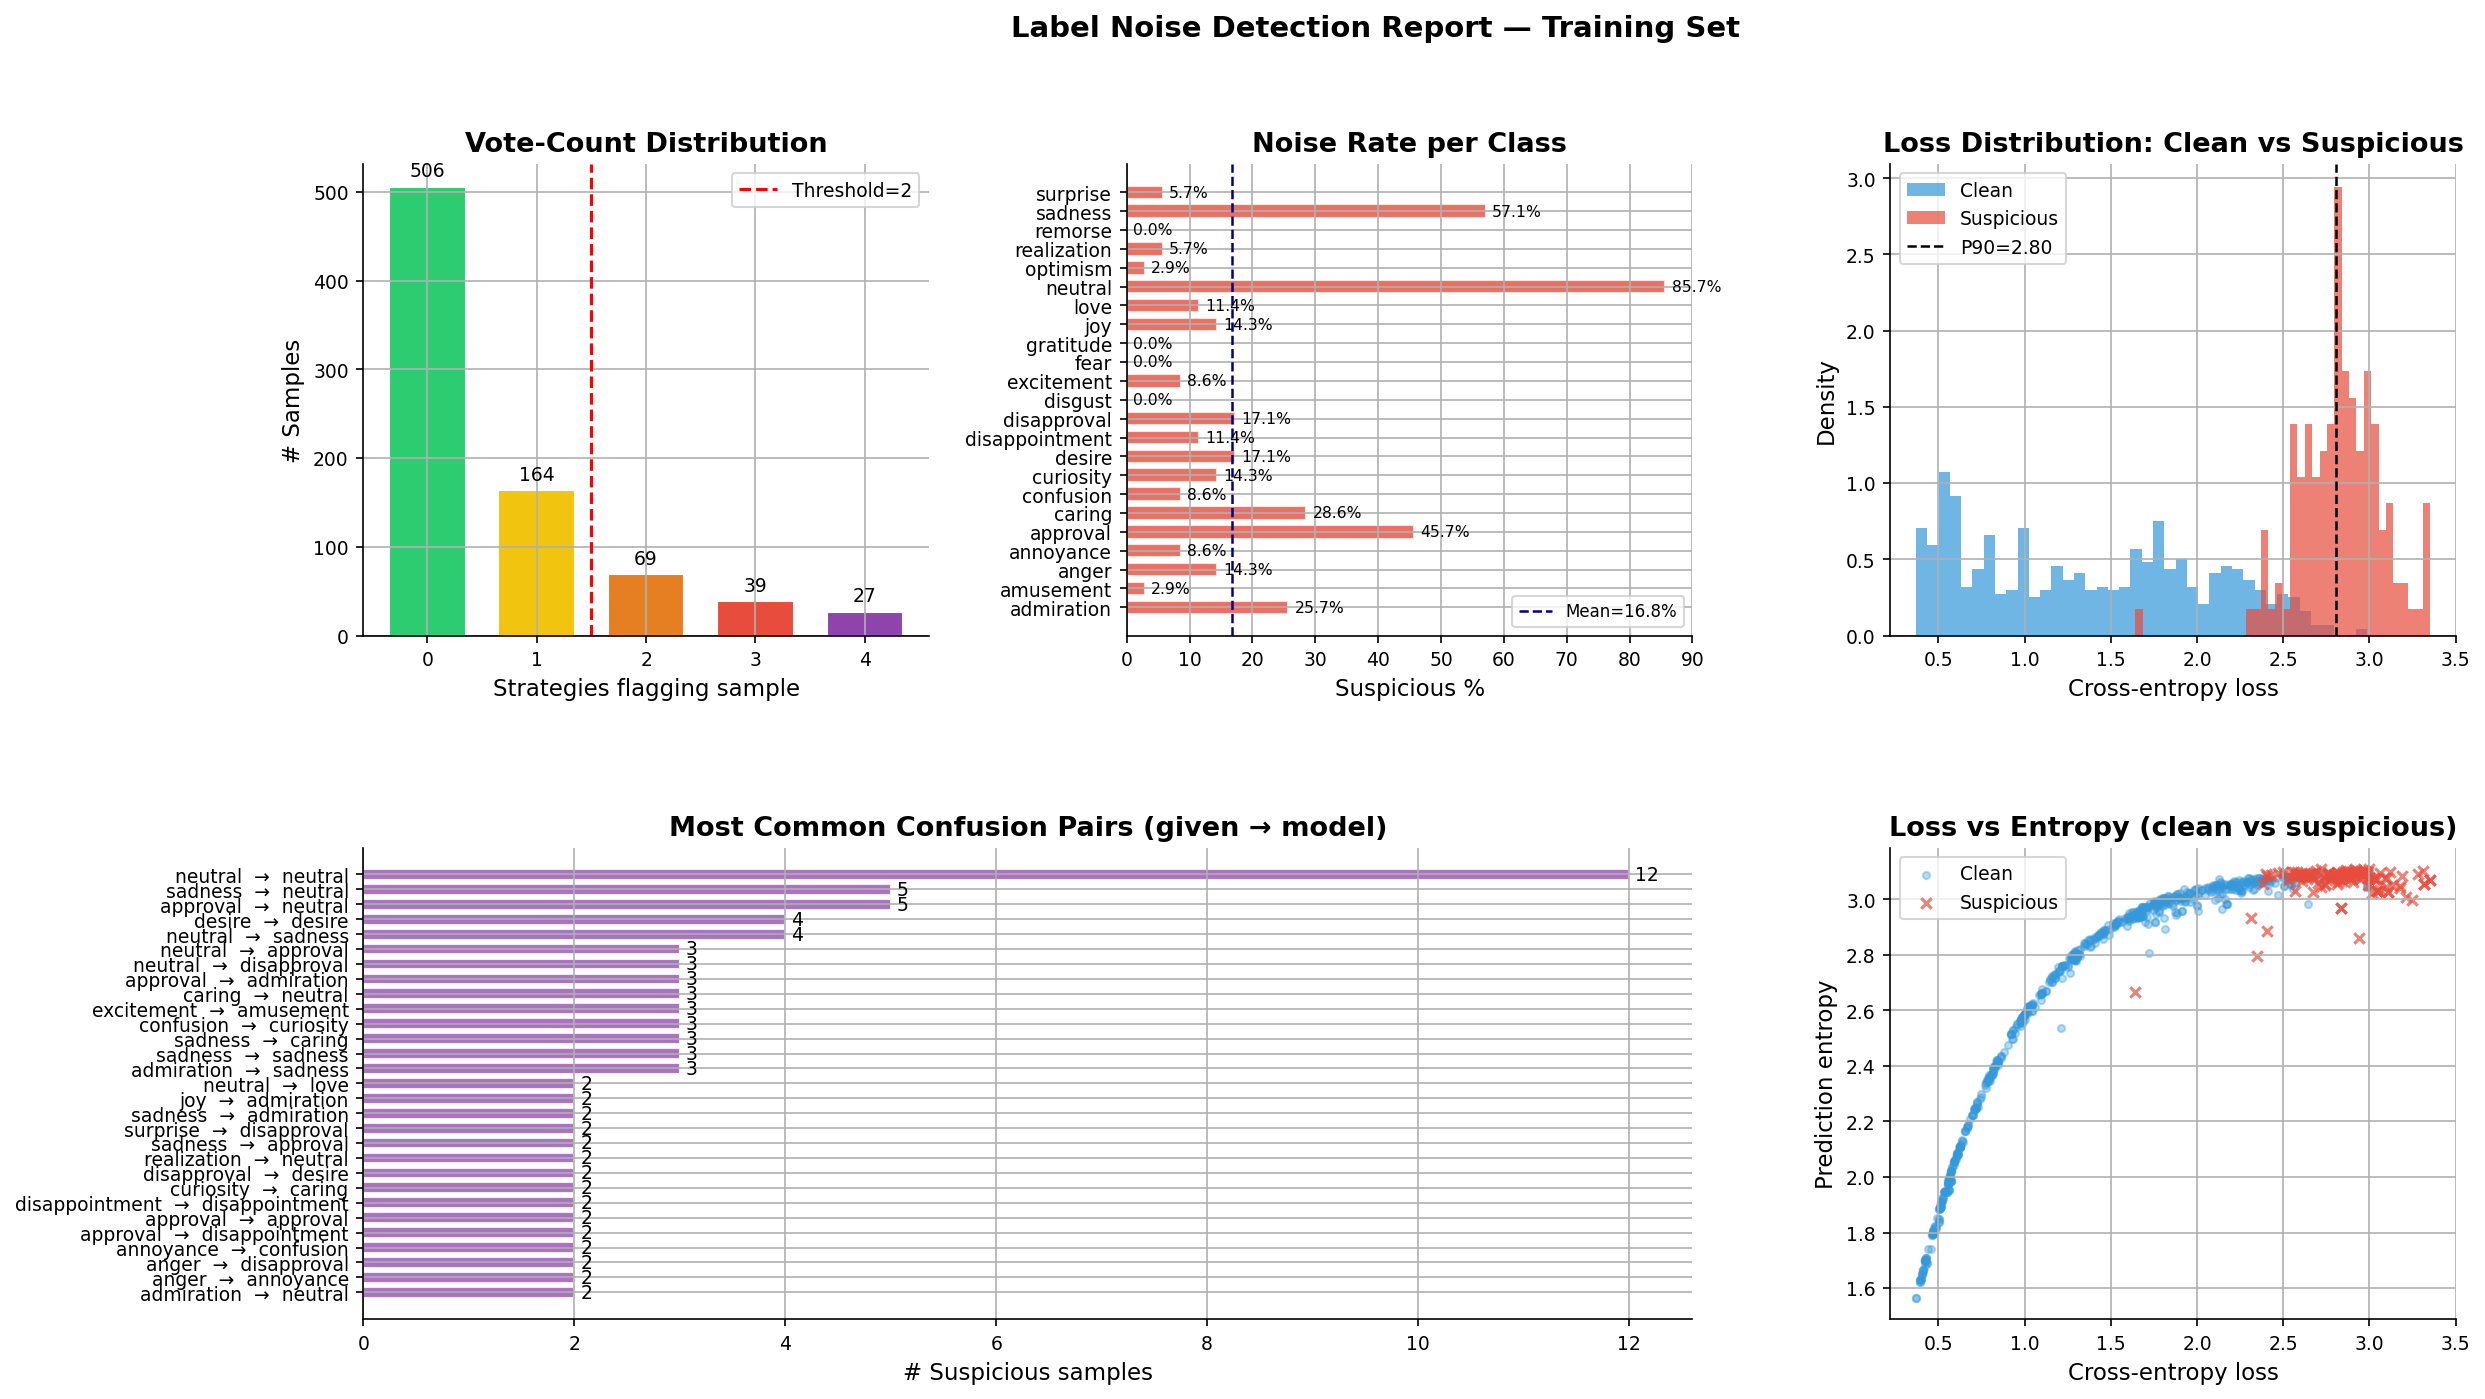


📊 Plot saved → /content/drive/MyDrive/NLP/ctg_fusion_figures/label_noise_report.pdf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Vote-count histogram ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts_hist = np.bincount(vote_count, minlength=5)
colors_h    = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
bars = ax1.bar(range(5), counts_hist, color=colors_h, edgecolor="white", width=0.7)
ax1.bar_label(bars, padding=3, fontsize=9)
ax1.axvline(VOTE_THRESH - 0.5, color="red", ls="--", lw=1.5, label=f"Threshold={VOTE_THRESH}")
ax1.set(xlabel="Strategies flagging sample", ylabel="# Samples",
        title="Vote-Count Distribution", xticks=range(5))
ax1.legend(fontsize=9)

# ── 2. Suspicious samples per class ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
susp_per_cls = pd.Series(_y[suspicious]).value_counts().sort_index()
total_per_cls = pd.Series(_y).value_counts().sort_index()
susp_rate   = (susp_per_cls / total_per_cls * 100).fillna(0)
cls_names   = [_le.classes_[i] for i in susp_rate.index]
hb = ax2.barh(cls_names, susp_rate.values,
              color="#e74c3c", alpha=0.8, edgecolor="white", height=0.72)
ax2.bar_label(hb, fmt="%.1f%%", padding=3, fontsize=7.5)
ax2.axvline(susp_rate.mean(), color="navy", ls="--", lw=1.2,
            label=f"Mean={susp_rate.mean():.1f}%")
ax2.set(xlabel="Suspicious %", title="Noise Rate per Class")
ax2.legend(fontsize=8)

# ── 3. Per-sample loss distribution ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(per_sample_loss[~suspicious], bins=40, color="#3498db",
         alpha=0.7, label="Clean", density=True)
ax3.hist(per_sample_loss[suspicious],  bins=40, color="#e74c3c",
         alpha=0.7, label="Suspicious", density=True)
ax3.axvline(loss_thresh, color="black", ls="--", lw=1.2, label=f"P90={loss_thresh:.2f}")
ax3.set(xlabel="Cross-entropy loss", ylabel="Density",
        title="Loss Distribution: Clean vs Suspicious")
ax3.legend(fontsize=9)

# ── 4. Confusion: given label vs surrogate top-1 prediction ──────────────────
ax4 = fig.add_subplot(gs[1, :2])
susp_df_tmp = _df[suspicious].copy()
susp_df_tmp["given_label"]  = _y[suspicious]
susp_df_tmp["model_top1"]   = oof_p[suspicious].argmax(axis=1)
susp_df_tmp["model_label"]  = [_le.classes_[i] for i in susp_df_tmp["model_top1"]]
confusion_pairs = (susp_df_tmp
                   .groupby([COL_LABEL, "model_label"])
                   .size().reset_index(name="count")
                   .query("count >= 2")
                   .sort_values("count", ascending=True))
hb2 = ax4.barh(
    confusion_pairs[COL_LABEL] + "  →  " + confusion_pairs["model_label"],
    confusion_pairs["count"],
    color="#9b59b6", alpha=0.85, edgecolor="white", height=0.72
)
ax4.bar_label(hb2, padding=3, fontsize=9)
ax4.set(xlabel="# Suspicious samples", title="Most Common Confusion Pairs (given → model)")

# ── 5. Entropy scatter: clean vs suspicious ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(per_sample_loss[~suspicious], entropy[~suspicious],
            c="#3498db", alpha=0.35, s=12, label="Clean")
ax5.scatter(per_sample_loss[suspicious],  entropy[suspicious],
            c="#e74c3c", alpha=0.7,  s=25, label="Suspicious", marker="x")
ax5.set(xlabel="Cross-entropy loss", ylabel="Prediction entropy",
        title="Loss vs Entropy (clean vs suspicious)")
ax5.legend(fontsize=9)

plt.suptitle("Label Noise Detection Report — Training Set",
             fontsize=14, fontweight="bold")
plt.savefig(f"{FIG_DIR}/label_noise_report.pdf", bbox_inches="tight")
plt.show()

print(f"\n📊 Plot saved → {FIG_DIR}/label_noise_report.pdf")


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# EXPORT suspicious rows for human review
# ════════════════════════════════════════════════════════════════════════════
susp_df = _df[suspicious].copy()
susp_df["given_label"]         = _df.loc[suspicious, COL_LABEL].values
susp_df["surrogate_top1"]      = [_le.classes_[i]
                                   for i in oof_p[suspicious].argmax(axis=1)]
susp_df["surrogate_top1_prob"] = oof_p[suspicious].max(axis=1).round(3)
susp_df["surrogate_top2"]      = [_le.classes_[np.argsort(p)[-2]]
                                   for p in oof_p[suspicious]]
susp_df["surrogate_top2_prob"] = [round(sorted(p)[-2], 3)
                                   for p in oof_p[suspicious]]
susp_df["loss"]                = per_sample_loss[suspicious].round(3)
susp_df["entropy"]             = entropy[suspicious].round(3)
susp_df["vote_count"]          = vote_count[suspicious]
susp_df["flagged_by_CL"]       = flag_cl[suspicious]
susp_df["flagged_by_loss"]     = flag_loss[suspicious]
susp_df["flagged_by_entropy"]  = flag_ent[suspicious]
susp_df["flagged_by_knn"]      = flag_knn[suspicious]
susp_df["review_action"]       = ""   # human fills: keep / relabel / remove

# Reorder columns for readability
review_cols = (ALL_TEXT_COLS +
               ["given_label", "surrogate_top1", "surrogate_top1_prob",
                "surrogate_top2", "surrogate_top2_prob",
                "vote_count", "loss", "entropy",
                "flagged_by_CL", "flagged_by_loss",
                "flagged_by_entropy", "flagged_by_knn",
                "review_action"])
susp_df[review_cols].to_csv(f"{DATA_DIR}/suspicious_labels.csv", index=True)

print(f"✅  Exported {len(susp_df)} suspicious rows →  {DATA_DIR}/suspicious_labels.csv")
print("\nTop-10 rows by vote count:")
display(susp_df[["given_label","surrogate_top1","surrogate_top1_prob",
                  "vote_count","loss"]].head(10).round(3))

# ════════════════════════════════════════════════════════════════════════════
# BUILD CLEANED TRAINING SPLITS
# Three options — pick based on your review:
#
#   Option A — Conservative: keep everything, down-weight suspicious rows
#              (safe; no data loss; smooths gradient signal from noisy rows)
#
#   Option B — Moderate: drop rows flagged by ≥ 3 strategies
#              (removes only the most clearly wrong rows)
#
#   Option C — Aggressive: drop all suspicious rows (≥ 2 strategies)
#              (use only if you've manually verified replacements)
# ════════════════════════════════════════════════════════════════════════════

NOISE_CLEAN_STRATEGY = "B"   # ← change to "A", "B", or "C"

if NOISE_CLEAN_STRATEGY == "A":
    # Down-weight suspicious rows in the FocalLoss via per-sample weight vector
    sample_weights = np.where(suspicious, 0.25, 1.0)  # suspicious → 25% weight
    train_df_clean = train_df.copy()
    print(f"\n[Option A] Keeping all rows; suspicious rows down-weighted to 0.25×")

elif NOISE_CLEAN_STRATEGY == "B":
    high_conf_susp = vote_count >= 3
    keep_mask      = ~high_conf_susp
    train_df_clean = train_df[keep_mask].reset_index(drop=True)
    sample_weights = np.ones(len(train_df_clean))
    print(f"\n[Option B] Dropped {high_conf_susp.sum()} rows (≥3/4 strategies)")
    print(f"           Training set: {len(train_df)} → {len(train_df_clean)}")

else:  # C
    keep_mask      = ~suspicious
    train_df_clean = train_df[keep_mask].reset_index(drop=True)
    sample_weights = np.ones(len(train_df_clean))
    print(f"\n[Option C] Dropped {suspicious.sum()} rows (≥2/4 strategies)")
    print(f"           Training set: {len(train_df)} → {len(train_df_clean)}")

train_df_clean.to_csv(f"{DATA_DIR}/train_clean.csv", index=False)
print(f"Clean training set saved → {DATA_DIR}/train_clean.csv")
print("⚠️  Re-run cells below this point with train_df = train_df_clean")


✅  Exported 135 suspicious rows →  /content/drive/MyDrive/NLP/CTG_Sentiment/suspicious_labels.csv

Top-10 rows by vote count:


,given_label,surrogate_top1,surrogate_top1_prob,vote_count,loss
4,anger,disapproval,0.100,3,3.046
11,sadness,caring,0.092,3,2.946
13,love,disapproval,0.085,3,2.817
19,approval,neutral,0.101,3,2.993
21,neutral,approval,0.080,2,2.859
29,admiration,sadness,0.068,3,2.792
30,neutral,neutral,0.090,2,2.407
38,neutral,neutral,0.064,2,2.753
48,anger,disapproval,0.143,3,3.213
60,joy,confusion,0.068,4,2.810



[Option B] Dropped 66 rows (≥3/4 strategies)
           Training set: 805 → 739
Clean training set saved → /content/drive/MyDrive/NLP/CTG_Sentiment/train_clean.csv
⚠️  Re-run cells below this point with train_df = train_df_clean


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SWAP IN CLEANED TRAINING DATA
# Run this cell ONCE after the noise detection above, then re-run all
# cells from the LabelEncoder onwards.
# ════════════════════════════════════════════════════════════════════════════

train_df = train_df_clean   # replace the global training DataFrame
TRAIN_CSV = f"{DATA_DIR}/train_clean.csv"

# If you used Option A (sample weights), pass sample_weights into the
# FusionDataset via a 'weight' column so the DataLoader can use them:
if NOISE_CLEAN_STRATEGY == "A":
    train_df = train_df.copy()
    train_df["_noise_weight"] = sample_weights  # read in FusionDataset.__getitem__

print(f"Active training set : {len(train_df)} rows  "
      f"(strategy={NOISE_CLEAN_STRATEGY})")
print("Re-run from the LabelEncoder cell onwards ↓")


Active training set : 739 rows  (strategy=B)
Re-run from the LabelEncoder cell onwards ↓


### 4.1 · Label Distribution & Token Lengths

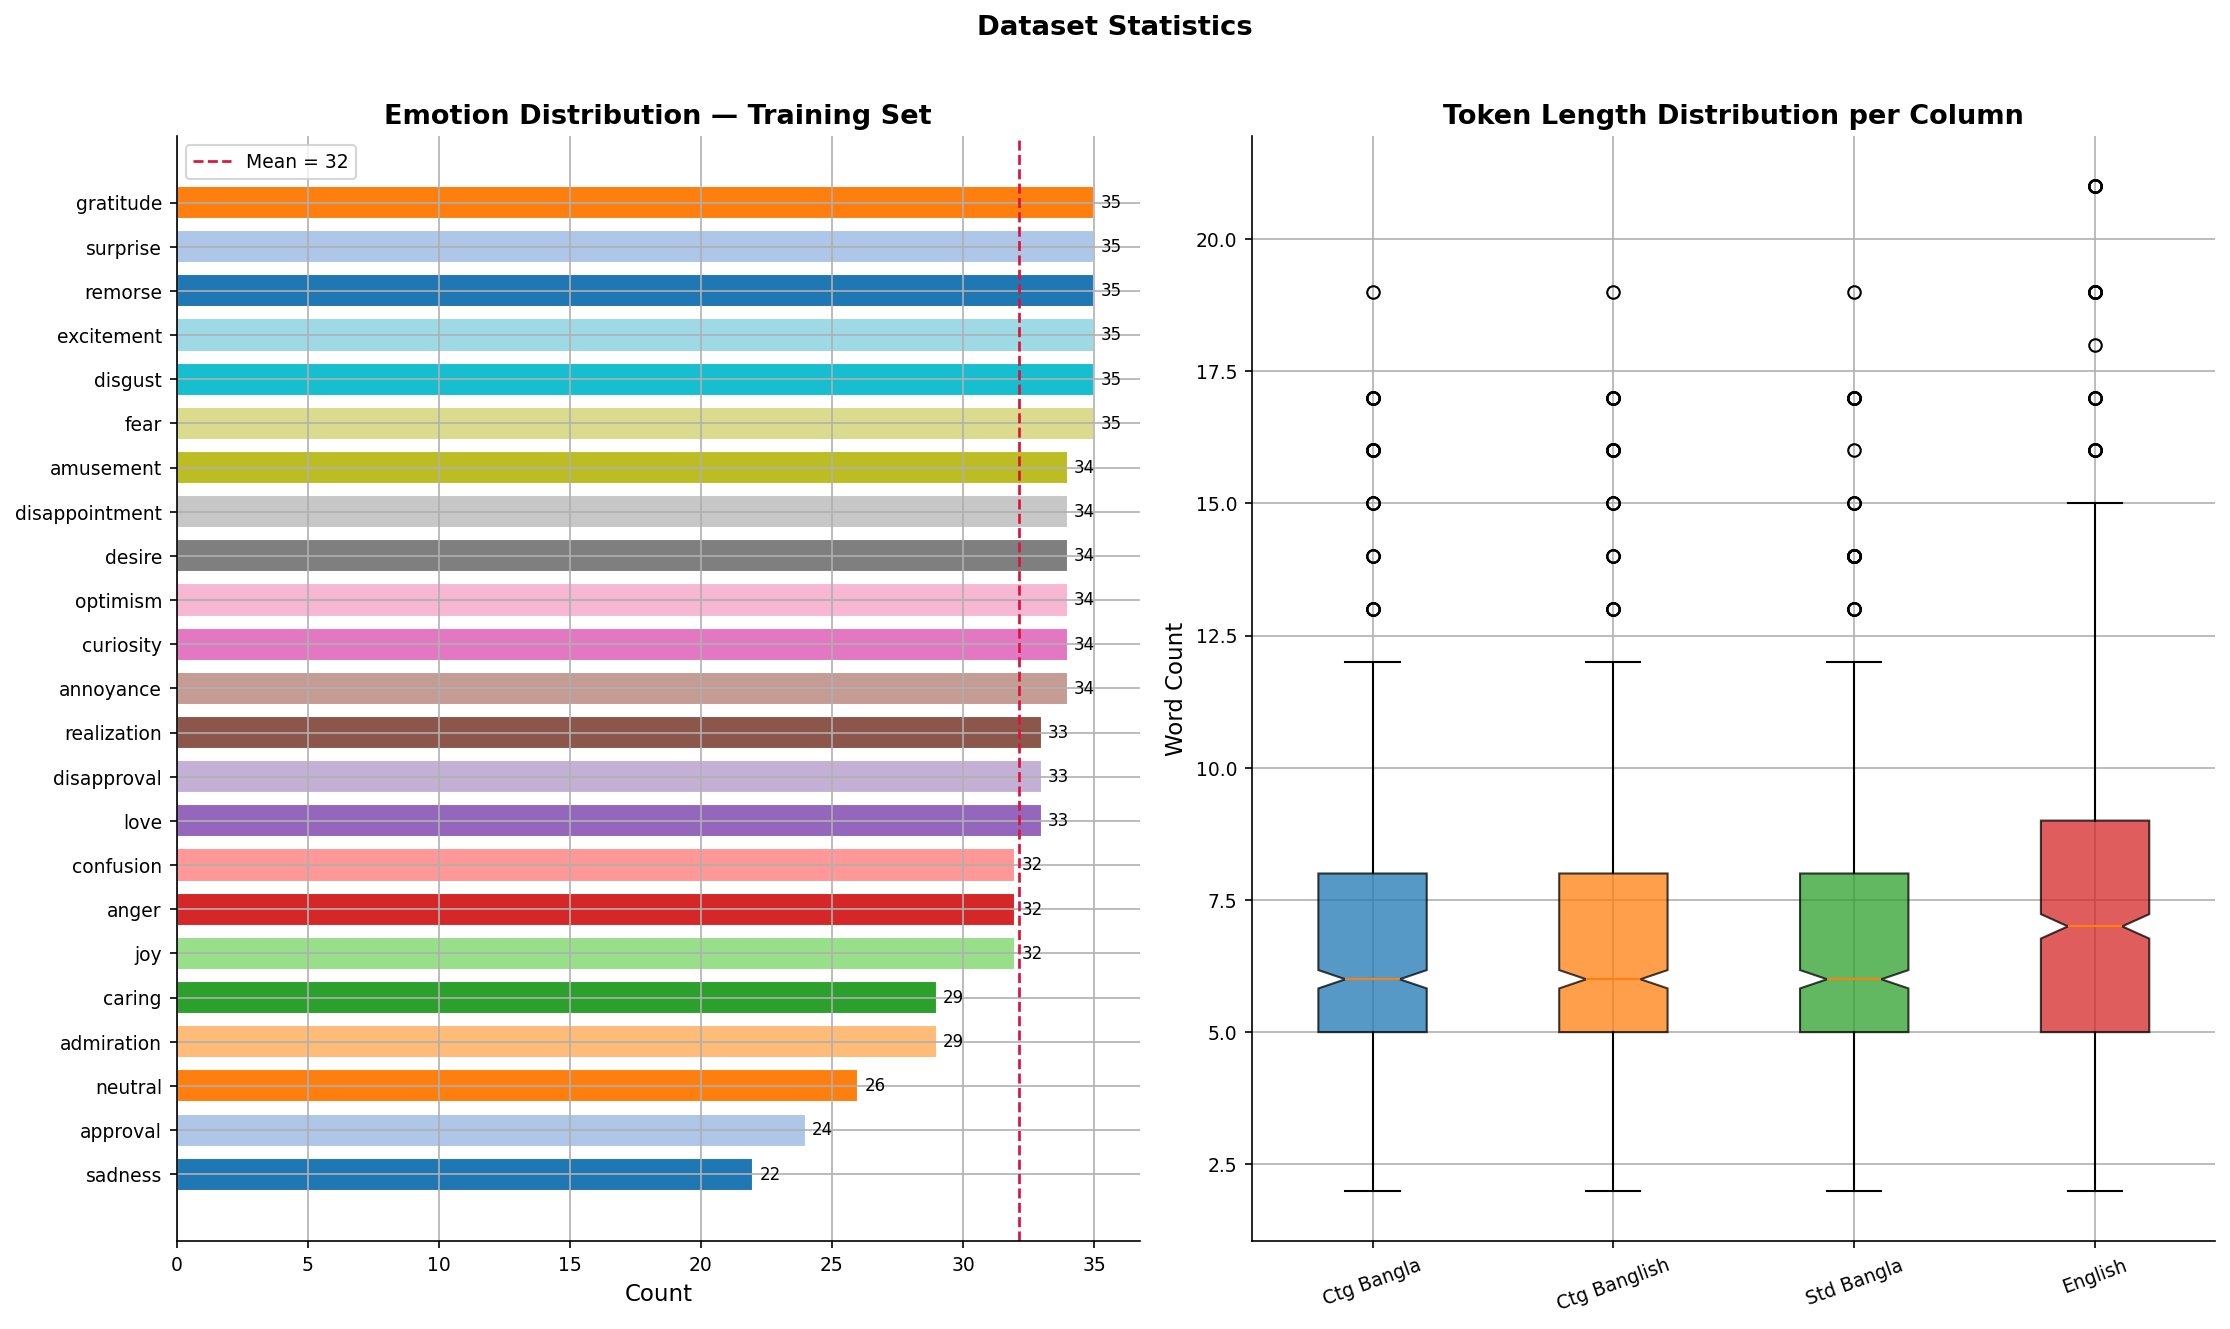

In [ ]:
cnt = train_df[COL_LABEL].value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(cnt)*0.38)))

# ── Left: distribution ────────────────────────────────────────────────────────
colors = [PAL20[i % 20] for i in range(len(cnt))]
hb = axes[0].barh(cnt.index, cnt.values, color=colors, edgecolor="white", height=0.75)
axes[0].bar_label(hb, padding=3, fontsize=8)
axes[0].axvline(cnt.mean(), color="crimson", ls="--", lw=1.3,
                label=f"Mean = {cnt.mean():.0f}")
axes[0].set(xlabel="Count", title="Emotion Distribution — Training Set")
axes[0].legend()

# ── Right: token length per column ────────────────────────────────────────────
col_lens = {c: train_df[c].astype(str).str.split().str.len() for c in ALL_TEXT_COLS}
col_labels = ["Ctg Bangla", "Ctg Banglish", "Std Bangla", "English"]
bp = axes[1].boxplot([col_lens[c] for c in ALL_TEXT_COLS],
                     labels=col_labels, patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], PAL10):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set(ylabel="Word Count", title="Token Length Distribution per Column")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Dataset Statistics", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_data_stats.pdf", bbox_inches="tight")
plt.show()

## 5 · Label Encoding & Class Weights

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(train_df[COL_LABEL])
y_val   = le.transform(val_df[COL_LABEL])
y_test  = le.transform(test_df[COL_LABEL])

NUM_LABELS = len(le.classes_)
label_map  = {i: c for i, c in enumerate(le.classes_)}
rev_map    = {c: i for i, c in label_map.items()}
print("Num labels:", NUM_LABELS)
print("Classes:", list(le.classes_))

cw = compute_class_weight("balanced", classes=np.arange(NUM_LABELS), y=y_train)
class_weights = torch.tensor(cw, dtype=torch.float).to(device)
print(f"Weight range: {cw.min():.3f} – {cw.max():.3f}")

Num labels: 23
Classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'excitement', 'fear', 'gratitude', 'joy', 'love', 'neutral', 'optimism', 'realization', 'remorse', 'sadness', 'surprise']
Weight range: 0.918 – 1.460


## 6 · Character Vocabulary

In [ ]:
PAD_CHAR, UNK_CHAR = "<PAD>", "<UNK>"

def build_char_vocab(series_list, min_freq=1):
    # FIX 7: min_freq=1 (was 2) — with ~800 samples many valid Chittagong
    # characters appear only once; min_freq=2 maps them to <UNK> silently
    counts = Counter()
    for s in series_list:
        for text in s.astype(str): counts.update(list(text))
    vocab = [PAD_CHAR, UNK_CHAR] + [c for c, n in counts.most_common() if n >= min_freq]
    return {c: i for i, c in enumerate(vocab)}

# Build vocab from ALL four text columns so both scripts are fully covered
char_vocab    = build_char_vocab([
    train_df[COL_CTG_BANGLA],
    train_df[COL_CTG_BANGLISH],
    train_df[COL_STD_BANGLA],
    train_df[COL_ENGLISH],
])
CHAR_VOCAB_SZ = len(char_vocab)
PAD_IDX       = char_vocab[PAD_CHAR]
UNK_IDX       = char_vocab[UNK_CHAR]

char_lens = (train_df[COL_CTG_BANGLA].astype(str).str.len().tolist() +
             train_df[COL_CTG_BANGLISH].astype(str).str.len().tolist())
MAX_CHAR_LEN = max(32, min(int(np.percentile(char_lens, 95)), 150))
print(f"Char vocab : {CHAR_VOCAB_SZ}  MAX_CHAR_LEN (p95): {MAX_CHAR_LEN}")

# Coverage check
unk_rate_ctg = train_df[COL_CTG_BANGLA].astype(str).apply(
    lambda t: sum(1 for c in t if c not in char_vocab) / max(len(t), 1)
).mean()
print(f"UNK rate in Ctg Bangla: {unk_rate_ctg*100:.2f}%  (target: <2%)")


Char vocab : 119  MAX_CHAR_LEN (p95): 60
UNK rate in Ctg Bangla: 0.00%  (target: <2%)


## 7 · Light Augmentation

In [ ]:
class LightAugmenter:
    def __init__(self, p_del=0.10, p_swap=0.10, prob=0.50):
        self.p_del  = p_del
        self.p_swap = p_swap
        self.prob   = prob

    def _delete(self, w):
        if len(w) <= 2: return w
        out = [x for x in w if random.random() > self.p_del]
        return out or [random.choice(w)]

    def _swap(self, w):
        if len(w) < 2: return w
        w = w[:]; i = random.randint(0, len(w)-2)
        w[i], w[i+1] = w[i+1], w[i]; return w

    def __call__(self, text):
        if random.random() > self.prob: return text
        words = str(text).split()
        op    = random.choice(["del", "swap", "both"])
        if op == "del":   words = self._delete(words)
        elif op == "swap": words = self._swap(words)
        else:             words = self._swap(self._delete(words))
        return " ".join(words) if words else text

augmenter = LightAugmenter()

## 8 · Pretrained Tokenisers

In [ ]:
bangla_tok  = AutoTokenizer.from_pretrained(BANGLABERT_NAME)
roberta_tok = AutoTokenizer.from_pretrained(ROBERTA_NAME)
print("BanglaBERT:", BANGLABERT_NAME)
print("RoBERTa   :", ROBERTA_NAME)

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BanglaBERT: csebuetnlp/banglabert
RoBERTa   : roberta-base


## 9 · Multi-Input Dataset & Collate

In [ ]:
class FusionDataset(Dataset):
    def __init__(self, df, y, btok, rtok, cvocab,
                 max_char, max_seq, augment=False):
        self.df       = df.reset_index(drop=True)
        self.y        = y
        self.btok     = btok
        self.rtok     = rtok
        self.cvocab   = cvocab
        self.max_char = max_char
        self.max_seq  = max_seq
        self.augment  = augment

    def __len__(self): return len(self.y)

    def _char_ids(self, text):
        return [self.cvocab.get(c, UNK_IDX) for c in str(text)[:self.max_char]]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        aug = augmenter if self.augment else (lambda x: x)
        ctg_ids    = self._char_ids(aug(row[COL_CTG_BANGLA]))
        ctg_bl_ids = self._char_ids(aug(row[COL_CTG_BANGLISH]))
        bb = self.btok(aug(row[COL_STD_BANGLA]),  truncation=True,
                       max_length=self.max_seq, return_tensors=None)
        rb = self.rtok(aug(row[COL_ENGLISH]),      truncation=True,
                       max_length=self.max_seq, return_tensors=None)
        return dict(ctg_ids=ctg_ids, ctg_bl_ids=ctg_bl_ids,
                    bb_input_ids=bb["input_ids"], bb_mask=bb["attention_mask"],
                    rb_input_ids=rb["input_ids"], rb_mask=rb["attention_mask"],
                    label=int(self.y[idx]))

def fusion_collate(batch):
    def pad_char(seqs):
        m = max(len(s) for s in seqs)
        return torch.tensor([s+[PAD_IDX]*(m-len(s)) for s in seqs], dtype=torch.long)
    def pad_seq(seqs):
        m = max(len(s) for s in seqs)
        return torch.tensor([s+[0]*(m-len(s)) for s in seqs], dtype=torch.long)
    return dict(
        ctg_ids      = pad_char([b["ctg_ids"]      for b in batch]),
        ctg_bl_ids   = pad_char([b["ctg_bl_ids"]   for b in batch]),
        ctg_len      = torch.tensor([len(b["ctg_ids"])    for b in batch]),
        ctg_bl_len   = torch.tensor([len(b["ctg_bl_ids"]) for b in batch]),
        bb_input_ids = pad_seq([b["bb_input_ids"]  for b in batch]),
        bb_mask      = pad_seq([b["bb_mask"]        for b in batch]),
        rb_input_ids = pad_seq([b["rb_input_ids"]  for b in batch]),
        rb_mask      = pad_seq([b["rb_mask"]        for b in batch]),
        labels       = torch.tensor([b["label"] for b in batch], dtype=torch.long),
    )

def make_loader(df, y, augment, bs, shuffle):
    ds = FusionDataset(df, y, bangla_tok, roberta_tok,
                       char_vocab, MAX_CHAR_LEN, MAX_SEQ_LEN, augment=augment)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=2, pin_memory=True, collate_fn=fusion_collate)

train_loader = make_loader(train_df, y_train, True,  BATCH_SIZE, True)
val_loader   = make_loader(val_df,   y_val,   False, BATCH_SIZE*2, False)
test_loader  = make_loader(test_df,  y_test,  False, BATCH_SIZE*2, False)
print(f"Loaders — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")

Loaders — train:47  val:6  test:6


## 10 · Model — Multi-Input Late Fusion

```
[Ctg Bangla]   char-ids → CharBiLSTM(64→128×2=256) → LayerNorm → Linear(256→256) → GELU ─┐
[Ctg Banglish] char-ids → CharBiLSTM(shared)         → LayerNorm → Linear(256→256) → GELU ─┤
[Std Bangla]   tok-ids  → BanglaBERT CLS(768)         → LayerNorm → Linear(768→256) → GELU ─┤ → cat(1024)
[English]      tok-ids  → RoBERTa-base CLS(768)       → LayerNorm → Linear(768→256) → GELU ─┘
                                                                         ↓
                                                           LayerNorm → Dropout(0.30)
                                                           Linear(1024→512) → GELU
                                                           Dropout(0.15) → Linear(512→23)
```

In [ ]:
class CharBiLSTMEncoder(nn.Module):
    """
    Character-level BiLSTM with attention pooling.

    FIX 8: attention pooling replaces mean pooling — captures morphological
    suffixes (-ইল, -তু, -উম) that carry tense/person meaning in Chittagong dialect.
    Mean pooling weights all positions equally; attention learns to up-weight
    the diagnostic suffix positions.
    """
    def __init__(self, vocab_sz, embed_dim, hidden_dim,
                 n_layers=2, dropout=0.45, pad_idx=0):  # OVERFIT FIX: was 0.30; higher char-BiLSTM dropout
        super().__init__()
        self.pad_idx = pad_idx
        self.embed   = nn.Embedding(vocab_sz, embed_dim, padding_idx=pad_idx)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if n_layers > 1 else 0.0)
        self.attn    = nn.Linear(hidden_dim * 2, 1)   # attention scorer
        self.drop    = nn.Dropout(dropout)

    def forward(self, ids, lengths):
        x      = self.drop(self.embed(ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu().clamp(min=1),
            batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)

        # ── Attention pooling (FIX 8) ─────────────────────────────────────────
        # Score each timestep, mask padding, softmax, weighted sum
        scores = self.attn(out).squeeze(-1)                   # (B, T)
        scores = scores.masked_fill(ids == self.pad_idx, -1e4)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        pooled  = (out * weights).sum(1)                      # (B, hidden*2)
        return self.drop(pooled)


class FusionClassifier(nn.Module):
    """
    4-branch late fusion:
      [Ctg Bangla]   → CharBiLSTM (dedicated)   → proj 256
      [Ctg Banglish] → CharBiLSTM (dedicated)   → proj 256   (FIX 9: NOT shared)
      [Std Bangla]   → BanglaBERT CLS            → proj 256
      [English]      → RoBERTa-base CLS           → proj 256
                                          → concat(1024) → head → 23 classes

    Key fixes vs v1:
      FIX 9:  separate (not shared) char encoders for Bengali vs Latin scripts
      FIX 10: higher head dropout (0.45/0.25 vs 0.30/0.15) to close train/val gap
      FIX 11: bottom FREEZE_BOTTOM_LAYERS transformer layers frozen to reduce overfit
    """
    def __init__(self, char_vocab_sz, num_labels,
                 proj_dim=256, fused_dim=1024,
                 char_embed=128, char_hidden=256):
        super().__init__()
        self.proj_dim = proj_dim

        # FIX 9: always separate encoders — Bengali script ≠ Latin script
        # Shared encoder forces a compromise representation that serves neither
        self.enc_ctg = CharBiLSTMEncoder(char_vocab_sz, char_embed, char_hidden)
        self.enc_bl  = CharBiLSTMEncoder(char_vocab_sz, char_embed, char_hidden)
        char_out = char_hidden * 2   # 512 (bidirectional)

        # Transformer backbones
        self.banglabert = AutoModel.from_pretrained(BANGLABERT_NAME)
        self.roberta    = AutoModel.from_pretrained(ROBERTA_NAME)

        # FIX 11: freeze bottom N transformer layers to reduce overfitting
        # Bottom layers encode generic language features already captured in pretraining
        for backbone in [self.banglabert, self.roberta]:
            # Unfreeze everything first
            for p in backbone.parameters():
                p.requires_grad_(True)
            # Then freeze bottom layers
            encoder_layers = backbone.encoder.layer
            for i, layer in enumerate(encoder_layers):
                if i < FREEZE_BOTTOM_LAYERS:
                    for p in layer.parameters():
                        p.requires_grad_(False)

        # Gradient checkpointing for memory efficiency
        self.banglabert.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={"use_reentrant": False})
        self.roberta.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={"use_reentrant": False})

        bb_hid = self.banglabert.config.hidden_size   # 768
        rb_hid = self.roberta.config.hidden_size      # 768

        # Projection heads → proj_dim each
        def _proj(in_dim):
            return nn.Sequential(
                nn.LayerNorm(in_dim),
                nn.Linear(in_dim, proj_dim),
                nn.GELU()
            )
        self.proj_ctg = _proj(char_out)
        self.proj_bl  = _proj(char_out)
        self.proj_bb  = _proj(bb_hid)
        self.proj_rb  = _proj(rb_hid)

        # FIX 10: higher dropout to close the 25× train/val loss gap
        mid = fused_dim // 2
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Dropout(0.45),             # was 0.30
            nn.Linear(fused_dim, mid),
            nn.GELU(),
            nn.Dropout(0.25),             # was 0.15
            nn.Linear(mid, num_labels),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)

        # Summary
        n_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_frozen    = sum(p.numel() for p in self.parameters() if not p.requires_grad)
        print(f"  Trainable params : {n_trainable/1e6:.1f}M")
        print(f"  Frozen params    : {n_frozen/1e6:.1f}M  (bottom {FREEZE_BOTTOM_LAYERS} layers)")

    def _encode_char(self, enc, proj, ids, lengths):
        return proj(enc(ids, lengths))

    def _encode_transformer(self, mdl, proj, input_ids, mask):
        out = mdl(input_ids=input_ids, attention_mask=mask)
        cls = out.last_hidden_state[:, 0, :]
        return proj(cls)

    def encode_branches(self, ctg_ids, ctg_len, ctg_bl_ids, ctg_bl_len,
                        bb_input_ids, bb_mask, rb_input_ids, rb_mask,
                        ablate=None):
        ablate = ablate or set()
        B  = ctg_ids.size(0)
        z  = lambda: torch.zeros(B, self.proj_dim, device=ctg_ids.device)

        v_ctg = z() if "ctg"      in ablate else self._encode_char(
            self.enc_ctg, self.proj_ctg, ctg_ids, ctg_len)
        v_bl  = z() if "banglish" in ablate else self._encode_char(
            self.enc_bl,  self.proj_bl,  ctg_bl_ids, ctg_bl_len)
        v_bb  = z() if "bangla"   in ablate else self._encode_transformer(
            self.banglabert, self.proj_bb, bb_input_ids, bb_mask)
        v_rb  = z() if "english"  in ablate else self._encode_transformer(
            self.roberta,    self.proj_rb, rb_input_ids, rb_mask)
        return v_ctg, v_bl, v_bb, v_rb

    def forward(self, ctg_ids, ctg_len, ctg_bl_ids, ctg_bl_len,
                bb_input_ids, bb_mask, rb_input_ids, rb_mask,
                ablate=None):
        v_ctg, v_bl, v_bb, v_rb = self.encode_branches(
            ctg_ids, ctg_len, ctg_bl_ids, ctg_bl_len,
            bb_input_ids, bb_mask, rb_input_ids, rb_mask, ablate=ablate)
        fused = torch.cat([v_ctg, v_bl, v_bb, v_rb], dim=-1)
        return self.head(fused)


model = FusionClassifier(
    char_vocab_sz = CHAR_VOCAB_SZ,
    num_labels    = NUM_LABELS,
    proj_dim      = PROJ_DIM,
    fused_dim     = FUSED_DIM,
    char_embed    = CHAR_EMBED_DIM,
    char_hidden   = CHAR_HIDDEN,
).to(device)

tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable: {tp/1e6:.1f}M params")


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
electra.embeddings.position_ids                   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params : 113.1M
  Frozen params    : 127.6M  (bottom 9 layers)

Total trainable: 113.1M params


## 11 · Loss — Fixed Focal + Label Smoothing

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, num_classes, gamma=2.0, smoothing=0.1, weight=None):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing
        self.register_buffer("weight", weight)

    def forward(self, logits, targets):
        logits    = logits.float()                       # fp16 → fp32 safety
        log_probs = F.log_softmax(logits, dim=-1)
        nll       = F.nll_loss(log_probs, targets,
                               weight=self.weight, reduction="none")
        uniform   = -log_probs.mean(dim=-1)
        ce        = (1 - self.smoothing)*nll + self.smoothing*uniform
        pt        = log_probs.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_w   = (1 - pt.detach()) ** self.gamma
        return (focal_w * ce).mean()

loss_fn = FocalLoss(NUM_LABELS, FOCAL_GAMMA, LABEL_SMOOTHING, class_weights)
print("Loss: Focal + Label Smoothing + Class Weights ✓")

Loss: Focal + Label Smoothing + Class Weights ✓


## 12 · Optimizer — Three LR Groups

In [ ]:
# ── FIX 12: Hard unfreeze guard + gradient flow assertion ─────────────────────
# Ensures backbones are trainable before building optimizer — catches the
# silent frozen-param bug that caused MuRIL to plateau in earlier experiments
print("Verifying parameter freeze state...")
for name, backbone in [("BanglaBERT", model.banglabert),
                        ("RoBERTa",    model.roberta)]:
    # Only top layers should be trainable (bottom FREEZE_BOTTOM_LAYERS frozen)
    trainable = sum(1 for p in backbone.parameters() if p.requires_grad)
    frozen    = sum(1 for p in backbone.parameters() if not p.requires_grad)
    assert trainable > 0, f"FATAL: {name} has zero trainable params!"
    print(f"  {name}: trainable={trainable}  frozen={frozen} ✓")

# Char encoders must be fully trainable
for name, enc in [("enc_ctg", model.enc_ctg), ("enc_bl", model.enc_bl)]:
    frozen = sum(1 for p in enc.parameters() if not p.requires_grad)
    assert frozen == 0, f"FATAL: {name} has {frozen} frozen params!"
print("  Char encoders: all trainable ✓")

# Verify they are separate (FIX 9 sanity check)
assert model.enc_ctg is not model.enc_bl,     "FATAL: enc_ctg and enc_bl are the same object — fix share_char!"
print("  enc_ctg is not enc_bl ✓  (separate encoders confirmed)")

# ── Build optimizer with 3 LR groups ─────────────────────────────────────────
no_decay = {"bias", "LayerNorm.weight", "layer_norm.weight"}
wd_fn    = lambda n: 0.0 if any(nd in n for nd in no_decay) else WEIGHT_DECAY

g_transformer, g_lstm, g_head = [], [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    if any(x in name for x in ["banglabert", "roberta"]):
        g_transformer.append({"params": [param], "lr": TRANSFORMER_LR,
                               "weight_decay": wd_fn(name)})
    elif "head" in name:
        g_head.append({"params": [param], "lr": HEAD_LR,
                        "weight_decay": wd_fn(name)})
    else:
        g_lstm.append({"params": [param], "lr": LSTM_LR,
                        "weight_decay": wd_fn(name)})

optimizer    = AdamW(g_transformer + g_lstm + g_head)
total_steps  = (len(train_loader) // ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps)
scaler       = GradScaler(DEVICE_STR)

print(f"\nOptimizer groups — transformer:{len(g_transformer)}"
      f"  lstm:{len(g_lstm)}  head:{len(g_head)}")
print(f"Steps — total:{total_steps}  warmup:{warmup_steps}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")


Verifying parameter freeze state...
  BanglaBERT: trainable=53  frozen=144 ✓
  RoBERTa: trainable=55  frozen=144 ✓
  Char encoders: all trainable ✓
  enc_ctg is not enc_bl ✓  (separate encoders confirmed)

Optimizer groups — transformer:108  lstm:54  head:6
Steps — total:345  warmup:41
Effective batch size: 32


## 13 · Evaluation Helper

In [ ]:
def move(batch):
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()}

def evaluate(mdl, loader, ablate=None):
    mdl.eval()
    all_y, all_pred, all_prob, total_loss = [], [], [], 0.0
    with torch.no_grad():
        for batch in loader:
            batch  = move(batch)
            labels = batch["labels"]
            with autocast(device_type=DEVICE_STR):
                logits = mdl(
                    ctg_ids=batch["ctg_ids"], ctg_len=batch["ctg_len"],
                    ctg_bl_ids=batch["ctg_bl_ids"], ctg_bl_len=batch["ctg_bl_len"],
                    bb_input_ids=batch["bb_input_ids"], bb_mask=batch["bb_mask"],
                    rb_input_ids=batch["rb_input_ids"], rb_mask=batch["rb_mask"],
                    ablate=ablate,
                )
                loss = loss_fn(logits, labels)
            total_loss += loss.item() * labels.size(0)
            probs = F.softmax(logits.float(), dim=1).cpu().numpy()
            preds = probs.argmax(1)
            all_y.extend(labels.cpu().numpy())
            all_pred.extend(preds)
            all_prob.extend(probs)
    n = len(loader.dataset)
    ay, ap, apr = np.array(all_y), np.array(all_pred), np.array(all_prob)
    return total_loss/n, accuracy_score(ay,ap), f1_score(ay,ap,average="macro"), ay, ap, apr

## 14 · Training Loop

In [ ]:
history = {"train_loss":[], "val_loss":[], "val_acc":[], "val_f1":[]}
best_f1, best_epoch, no_improve = 0.0, 0, 0
gap_overfit_count = 0          # OVERFIT FIX: consecutive epochs with gap > 12×
GAP_HARD_LIMIT    = 12.0       # OVERFIT FIX: hard brake threshold
GAP_PATIENCE      = 2          # OVERFIT FIX: stop after this many consecutive gap violations

print(f"Training for up to {EPOCHS} epochs  "
      f"(early stop patience={EARLY_STOP})")
print(f"Frozen transformer layers: 0–{FREEZE_BOTTOM_LAYERS-1}  "
      f"(fine-tuning layers {FREEZE_BOTTOM_LAYERS}+)")
print("—" * 70)

for epoch in range(1, EPOCHS+1):
    model.train()
    train_sum = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        batch  = move(batch)
        labels = batch["labels"]
        with autocast(device_type=DEVICE_STR):
            logits = model(
                ctg_ids=batch["ctg_ids"],       ctg_len=batch["ctg_len"],
                ctg_bl_ids=batch["ctg_bl_ids"], ctg_bl_len=batch["ctg_bl_len"],
                bb_input_ids=batch["bb_input_ids"], bb_mask=batch["bb_mask"],
                rb_input_ids=batch["rb_input_ids"], rb_mask=batch["rb_mask"],
            )
            loss = loss_fn(logits, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()
        train_sum += loss.item() * ACCUM_STEPS * labels.size(0)

        if (step+1) % ACCUM_STEPS == 0 or (step+1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

    avg_tr = train_sum / len(train_loader.dataset)
    vl, va, vf, *_ = evaluate(model, val_loader)

    history["train_loss"].append(avg_tr)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf)

    # FIX 13: show train/val gap ratio — key overfit diagnostic
    gap_ratio = vl / max(avg_tr, 1e-9)
    gap_warn  = "  ⚠ OVERFIT" if gap_ratio > 10 else ""

    flag = "  ← best" if vf > best_f1 else ""
    print(f"Ep {epoch:3d}/{EPOCHS}  tr={avg_tr:.4f}  vl={vl:.4f}"
          f"  gap={gap_ratio:.1f}×  acc={va:.4f}  F1={vf:.4f}{flag}{gap_warn}")

    if vf > best_f1:
        best_f1, best_epoch, no_improve = vf, epoch, 0
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        torch.save(char_vocab,         f"{SAVE_DIR}/char_vocab.pt")
        with open(f"{SAVE_DIR}/label_map.json","w",encoding="utf-8") as f:
            json.dump(label_map, f, ensure_ascii=False, indent=2)
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP:
            print(f"Early stop (F1 patience) — best epoch {best_epoch}  F1={best_f1:.4f}")
            break

    # OVERFIT FIX: hard-brake on runaway gap ratio
    if gap_ratio > GAP_HARD_LIMIT:
        gap_overfit_count += 1
        if gap_overfit_count >= GAP_PATIENCE:
            print(f"Early stop (gap={gap_ratio:.1f}× > {GAP_HARD_LIMIT}× for "
                  f"{GAP_PATIENCE} epochs) — best epoch {best_epoch}  F1={best_f1:.4f}")
            break
    else:
        gap_overfit_count = 0  # reset counter when gap recovers

print(f"\nDone.  Best Val F1={best_f1:.4f} @ epoch {best_epoch}")



Training for up to 15 epochs  (early stop patience=2)
Frozen transformer layers: 0–8  (fine-tuning layers 9+)
——————————————————————————————————————————————————————————————————————


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Ep   1/15  tr=2.9786  vl=2.9332  gap=1.0×  acc=0.0756  F1=0.0285  ← best
Ep   2/15  tr=2.8682  vl=2.7959  gap=1.0×  acc=0.1337  F1=0.0956  ← best
Ep   3/15  tr=2.5320  vl=2.1648  gap=0.9×  acc=0.3721  F1=0.3279  ← best
Ep   4/15  tr=1.7218  vl=1.3617  gap=0.8×  acc=0.6628  F1=0.6245  ← best
Ep   5/15  tr=0.8070  vl=0.9507  gap=1.2×  acc=0.7384  F1=0.7080  ← best
Ep   6/15  tr=0.4689  vl=0.8252  gap=1.8×  acc=0.7965  F1=0.7783  ← best
Ep   7/15  tr=0.2916  vl=0.7883  gap=2.7×  acc=0.8140  F1=0.8007  ← best
Ep   8/15  tr=0.2250  vl=0.8708  gap=3.9×  acc=0.7791  F1=0.7602
Ep   9/15  tr=0.1602  vl=0.7744  gap=4.8×  acc=0.7965  F1=0.7882
Early stop (F1 patience) — best epoch 7  F1=0.8007

Done.  Best Val F1=0.8007 @ epoch 7


## 15 · Training History

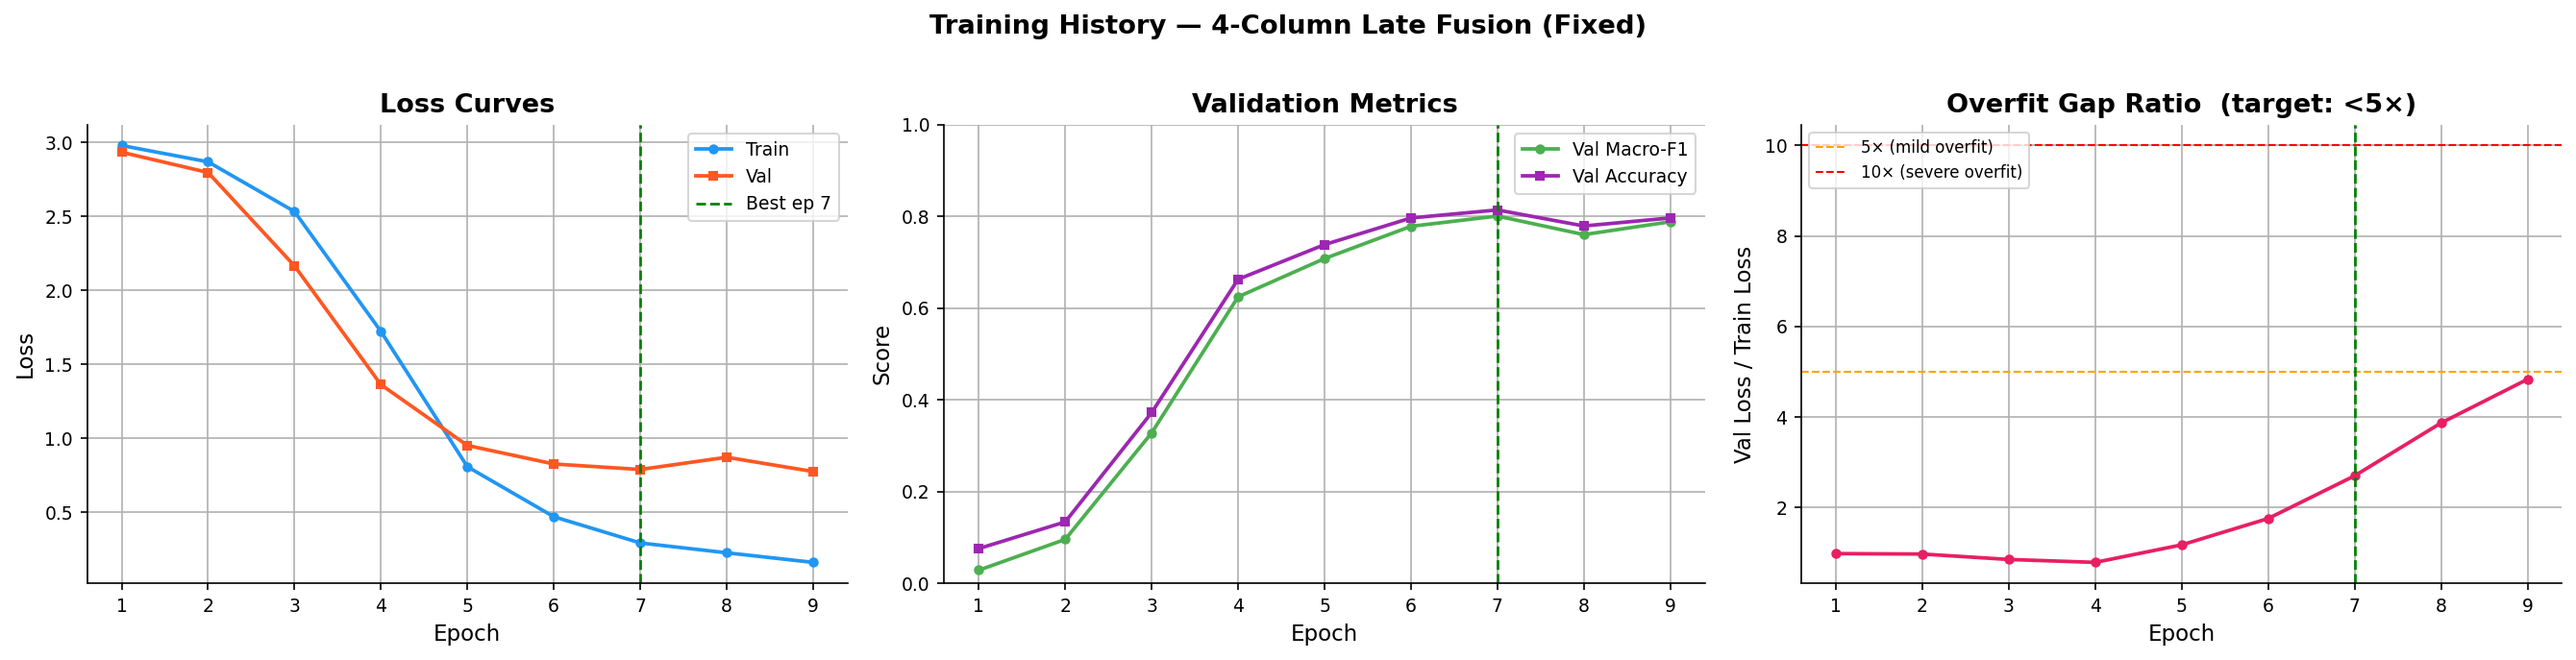

Final train/val loss gap: 4.8×  (acceptable)


In [ ]:
ep = list(range(1, len(history["train_loss"])+1))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Loss curves
axes[0].plot(ep, history["train_loss"], "o-", label="Train",
             color="#2196F3", lw=1.8, ms=4)
axes[0].plot(ep, history["val_loss"],   "s-", label="Val",
             color="#FF5722", lw=1.8, ms=4)
axes[0].axvline(best_epoch, color="green", ls="--", lw=1.3,
                label=f"Best ep {best_epoch}")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss Curves")
axes[0].legend()

# Metrics
axes[1].plot(ep, history["val_f1"],  "o-", label="Val Macro-F1",
             color="#4CAF50", lw=1.8, ms=4)
axes[1].plot(ep, history["val_acc"], "s-", label="Val Accuracy",
             color="#9C27B0", lw=1.8, ms=4)
axes[1].axvline(best_epoch, color="green", ls="--", lw=1.3)
axes[1].set(xlabel="Epoch", ylabel="Score",
            title="Validation Metrics", ylim=(0, 1))
axes[1].legend()

# FIX 13: Train/Val loss gap ratio — overfit diagnostic
gap = [v/max(t,1e-9)
       for t, v in zip(history["train_loss"], history["val_loss"])]
axes[2].plot(ep, gap, "o-", color="#E91E63", lw=1.8, ms=4)
axes[2].axhline(5,  color="orange", ls="--", lw=1, label="5× (mild overfit)")
axes[2].axhline(10, color="red",    ls="--", lw=1, label="10× (severe overfit)")
axes[2].axvline(best_epoch, color="green", ls="--", lw=1.3)
axes[2].set(xlabel="Epoch", ylabel="Val Loss / Train Loss",
            title="Overfit Gap Ratio  (target: <5×)")
axes[2].legend(fontsize=8)

plt.suptitle("Training History — 4-Column Late Fusion (Fixed)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_training_history.pdf", bbox_inches="tight")
plt.show()

# Print summary
final_gap = history["val_loss"][-1] / max(history["train_loss"][-1], 1e-9)
print(f"Final train/val loss gap: {final_gap:.1f}×"
      f"  ({'acceptable' if final_gap < 5 else 'still overfitting — see recommendations'})")


## 16 · Test Evaluation

In [ ]:
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pt", map_location=device))
test_loss, test_acc, test_f1, test_y, test_pred, test_probs = evaluate(model, test_loader)

print("═"*52)
print(f"  TEST  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  TEST  Macro-F1 : {test_f1:.4f}")
print(f"  TEST  Loss     : {test_loss:.4f}")
print("═"*52)

target_names = [label_map[i] for i in range(NUM_LABELS)]
print(classification_report(test_y, test_pred, target_names=target_names, digits=4))

════════════════════════════════════════════════════
  TEST  Accuracy : 0.8439  (84.39 %)
  TEST  Macro-F1 : 0.8378
  TEST  Loss     : 0.6707
════════════════════════════════════════════════════
                precision    recall  f1-score   support

    admiration     1.0000    0.5714    0.7273         7
     amusement     1.0000    1.0000    1.0000         7
         anger     0.5714    0.5714    0.5714         7
     annoyance     1.0000    1.0000    1.0000         8
      approval     0.6250    0.6250    0.6250         8
        caring     0.7778    1.0000    0.8750         7
     confusion     0.8750    0.8750    0.8750         8
     curiosity     0.7273    1.0000    0.8421         8
        desire     1.0000    0.8571    0.9231         7
disappointment     0.8750    1.0000    0.9333         7
   disapproval     0.5455    0.7500    0.6316         8
       disgust     1.0000    1.0000    1.0000         7
    excitement     0.8750    1.0000    0.9333         7
          fear     0

---
## A · Linguistic Case Study
### Sentence: *ইচ্ছে আসিল হোনো মিক্কে ঘুইরতু যাইয়্যুম*
**Natural English:** *"I felt like going somewhere just to roam around"*

| Token | Std Bangla | English | Dialectal Feature |
|---|---|---|---|
| ইচ্ছে | ইচ্ছে | desire / wish | Shared — no mutation |
| আসিল | এলো | arose / came | **-ইল** past suffix (Std: **-ল**) |
| হোনো | কোনো | somewhere | **ক→হ** onset shift |
| মিক্কে | দিকে | towards | **দ→ম** consonant mutation + vowel shift |
| ঘুইরতু | ঘুরতে | to roam | **-তু** infinitive (Std: **-তে**) |
| যাইয়্যুম | যেতাম/যাব | I would go | **-উম** desiderative future (1st person) |

**Ground-truth emotion: `desire`** — an active, unfulfilled, forward-looking wish.  
- No negation (নাই/না/হইল না) → not `disappointment`  
- Desiderative future, not past completed → not `joy` or `remorse`  
- Positive valence, anticipatory → not `sadness`

**Expected top-3:** desire → optimism → excitement

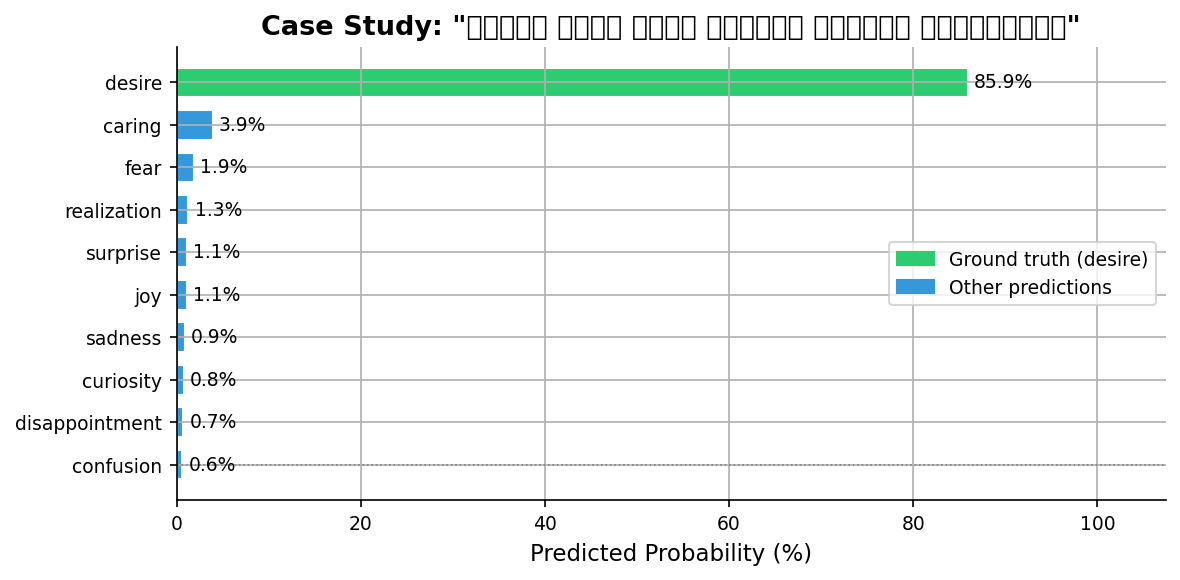

Predicted : desire  (✓ CORRECT)
Confidence: 85.9%
True label: desire  (rank #1 in predictions)


In [ ]:
# ── Predict on the case study sentence ────────────────────────────────────────
CASE = {
    COL_CTG_BANGLA:   "ইচ্ছে আসিল হোনো মিক্কে ঘুইরতু যাইয়্যুম",
    COL_CTG_BANGLISH: "icche asilo hono mikke ghuirtu jaiiyum",
    COL_STD_BANGLA:   "ইচ্ছা ছিল কোনো জায়গায় ঘুরতে যাব",
    COL_ENGLISH:      "I wanted to go somewhere",
    COL_LABEL:        "desire",
}

case_df = pd.DataFrame([CASE])
case_ds = FusionDataset(case_df, [rev_map["desire"]], bangla_tok, roberta_tok,
                        char_vocab, MAX_CHAR_LEN, MAX_SEQ_LEN, augment=False)
case_batch = move(fusion_collate([case_ds[0]]))

model.eval()
with torch.no_grad():
    case_logits = model(
        ctg_ids=case_batch["ctg_ids"], ctg_len=case_batch["ctg_len"],
        ctg_bl_ids=case_batch["ctg_bl_ids"], ctg_bl_len=case_batch["ctg_bl_len"],
        bb_input_ids=case_batch["bb_input_ids"], bb_mask=case_batch["bb_mask"],
        rb_input_ids=case_batch["rb_input_ids"], rb_mask=case_batch["rb_mask"],
    )
case_probs = F.softmax(case_logits.float(), dim=1).squeeze().cpu().numpy()
sorted_idx = np.argsort(case_probs)[::-1]

# ── Visualise: top-10 predicted emotions ──────────────────────────────────────
top10_idx   = sorted_idx[:10]
top10_lbl   = [label_map[i] for i in top10_idx]
top10_prob  = case_probs[top10_idx]
bar_colors  = ["#2ecc71" if label_map[i]=="desire" else "#3498db" for i in top10_idx]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top10_lbl[::-1], top10_prob[::-1]*100,
               color=bar_colors[::-1], edgecolor="white", height=0.7)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set(xlabel="Predicted Probability (%)",
       title='Case Study: "ইচ্ছে আসিল হোনো মিক্কে ঘুইরতু যাইয়্যুম"',
       xlim=(0, max(top10_prob)*100*1.25))
ax.axhline(len(top10_lbl)-1-list(top10_lbl[::-1]).index("desire"),
           color="gray", ls=":", lw=0.8)
correct_patch = mpatches.Patch(color="#2ecc71", label="Ground truth (desire)")
other_patch   = mpatches.Patch(color="#3498db", label="Other predictions")
ax.legend(handles=[correct_patch, other_patch], fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/A_case_study.pdf", bbox_inches="tight")
plt.show()

pred_emotion = label_map[sorted_idx[0]]
is_correct   = pred_emotion == "desire"
print(f"Predicted : {pred_emotion}  ({'✓ CORRECT' if is_correct else '✗ WRONG'})")
print(f"Confidence: {case_probs[sorted_idx[0]]*100:.1f}%")
print(f"True label: desire  (rank #{list(sorted_idx).index(rev_map['desire'])+1} in predictions)")

## B · Confusion Matrix — Publication Quality

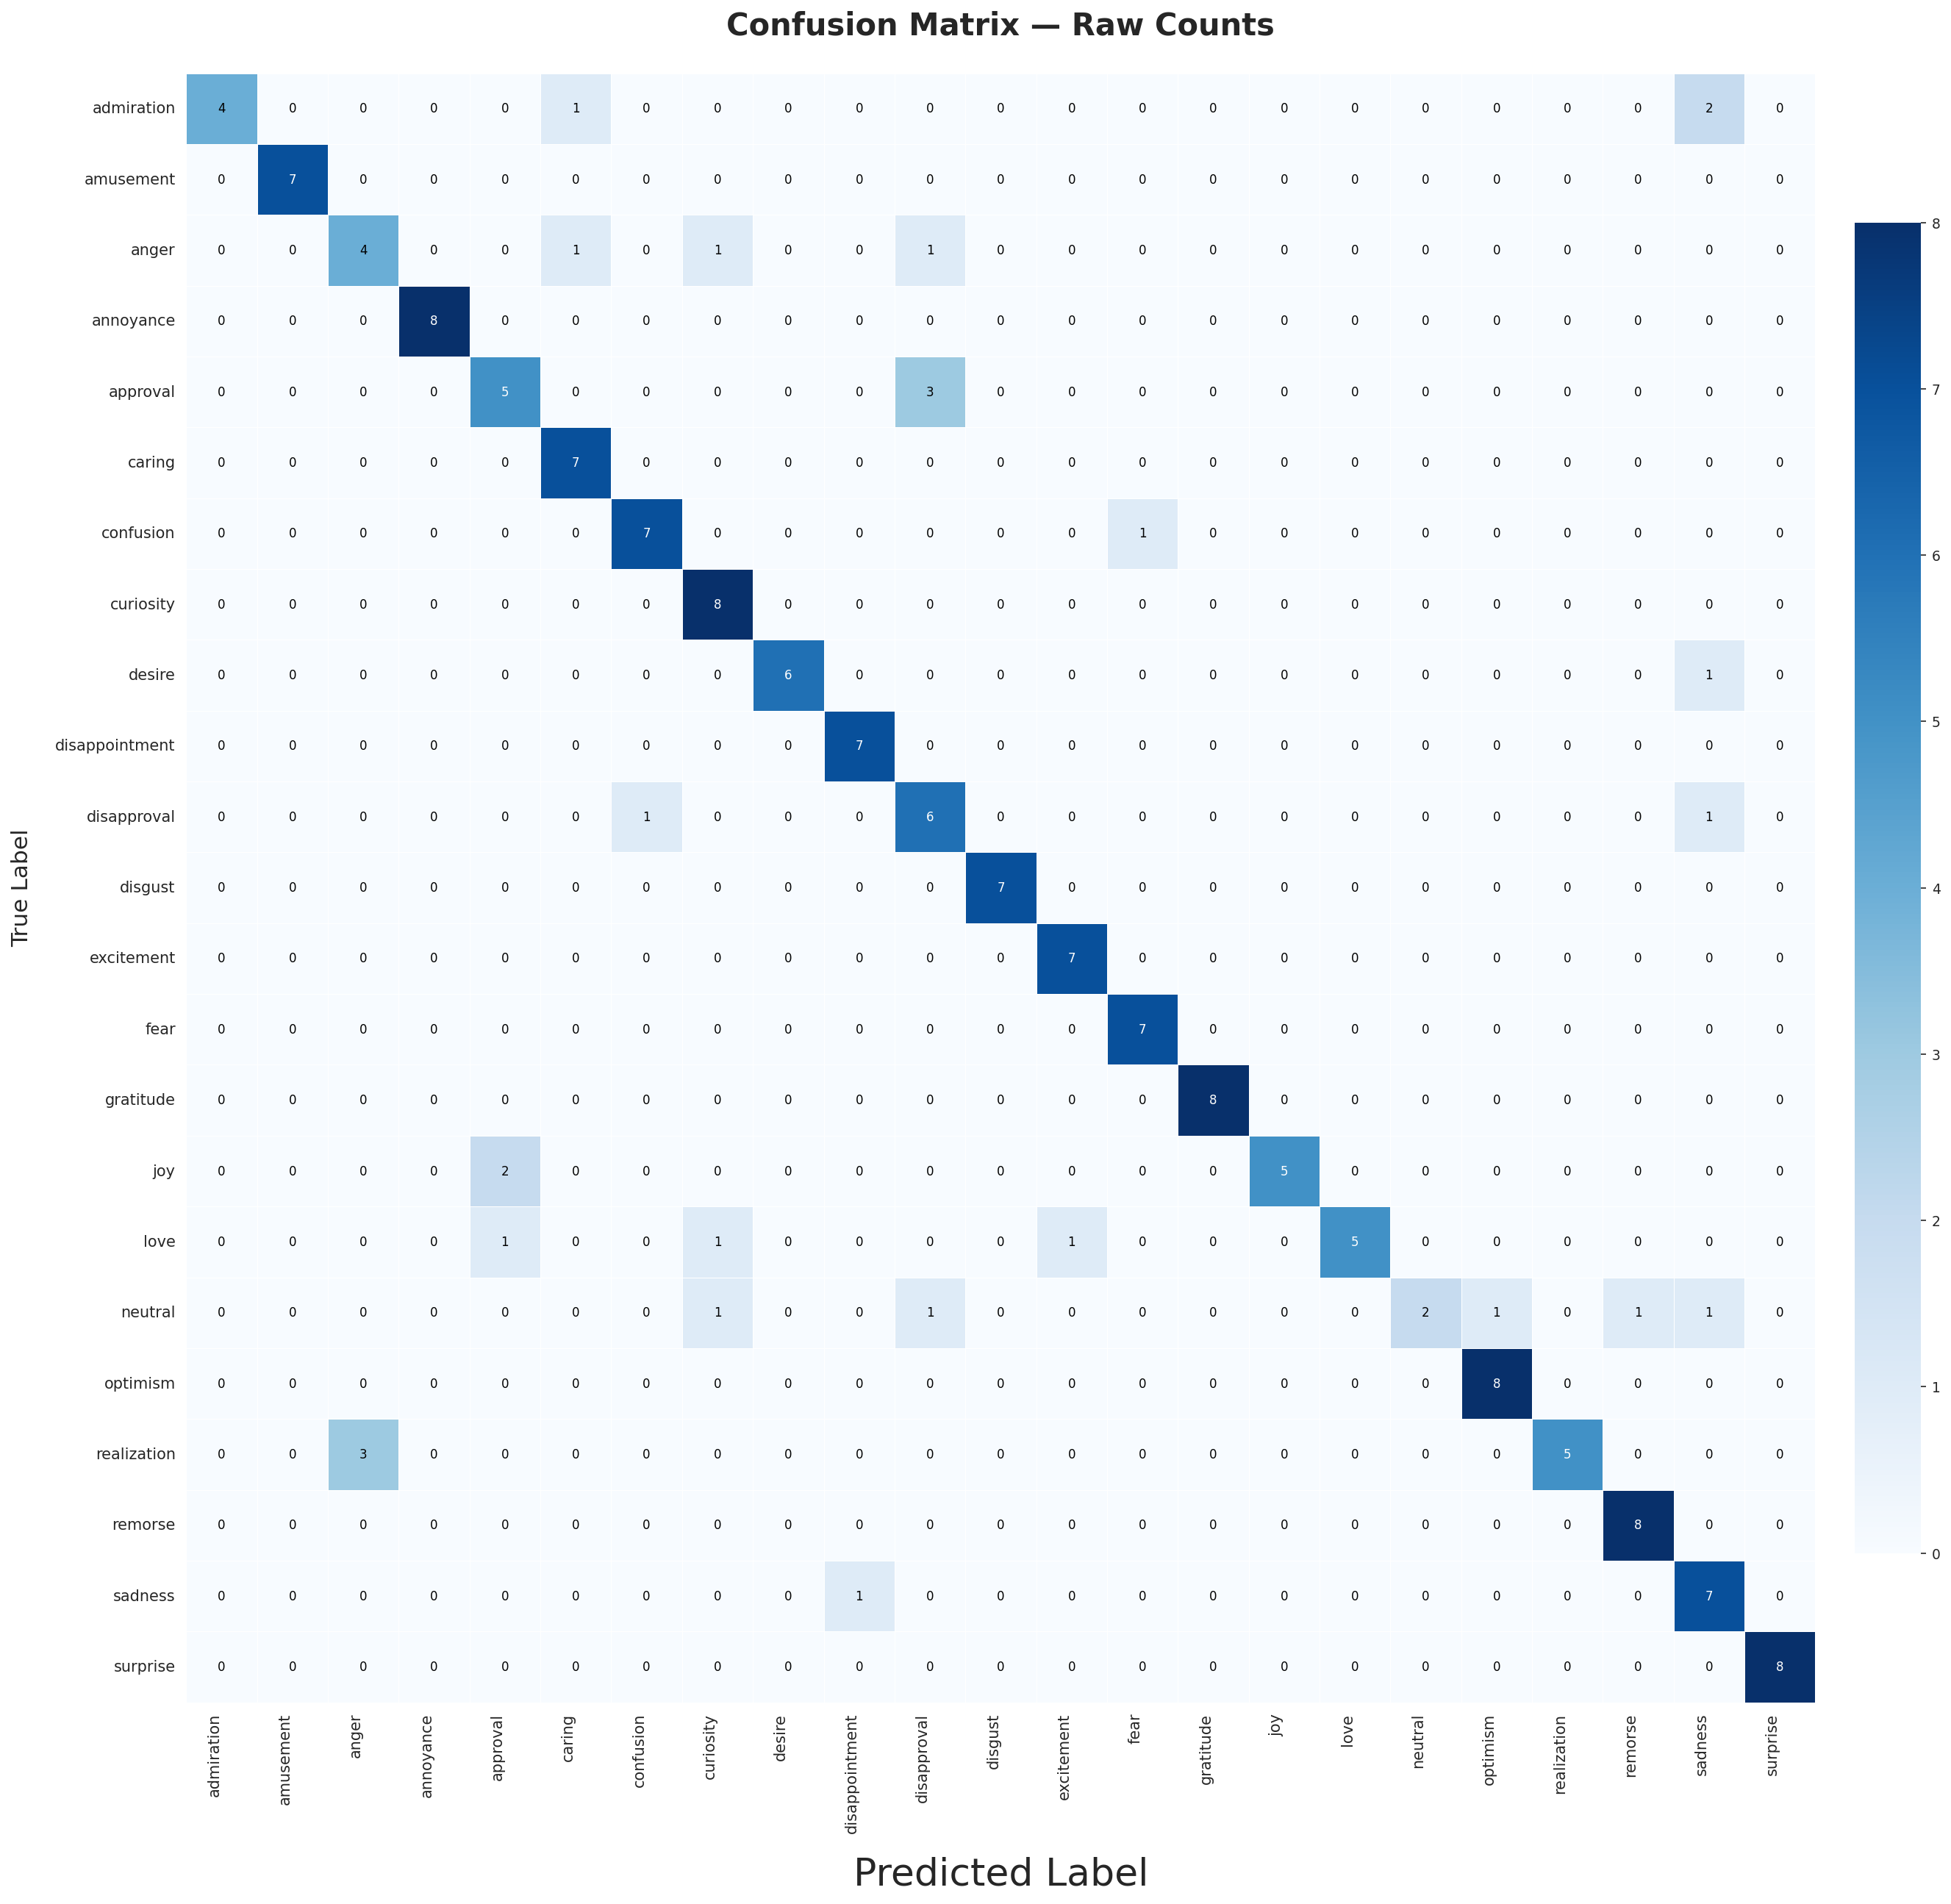

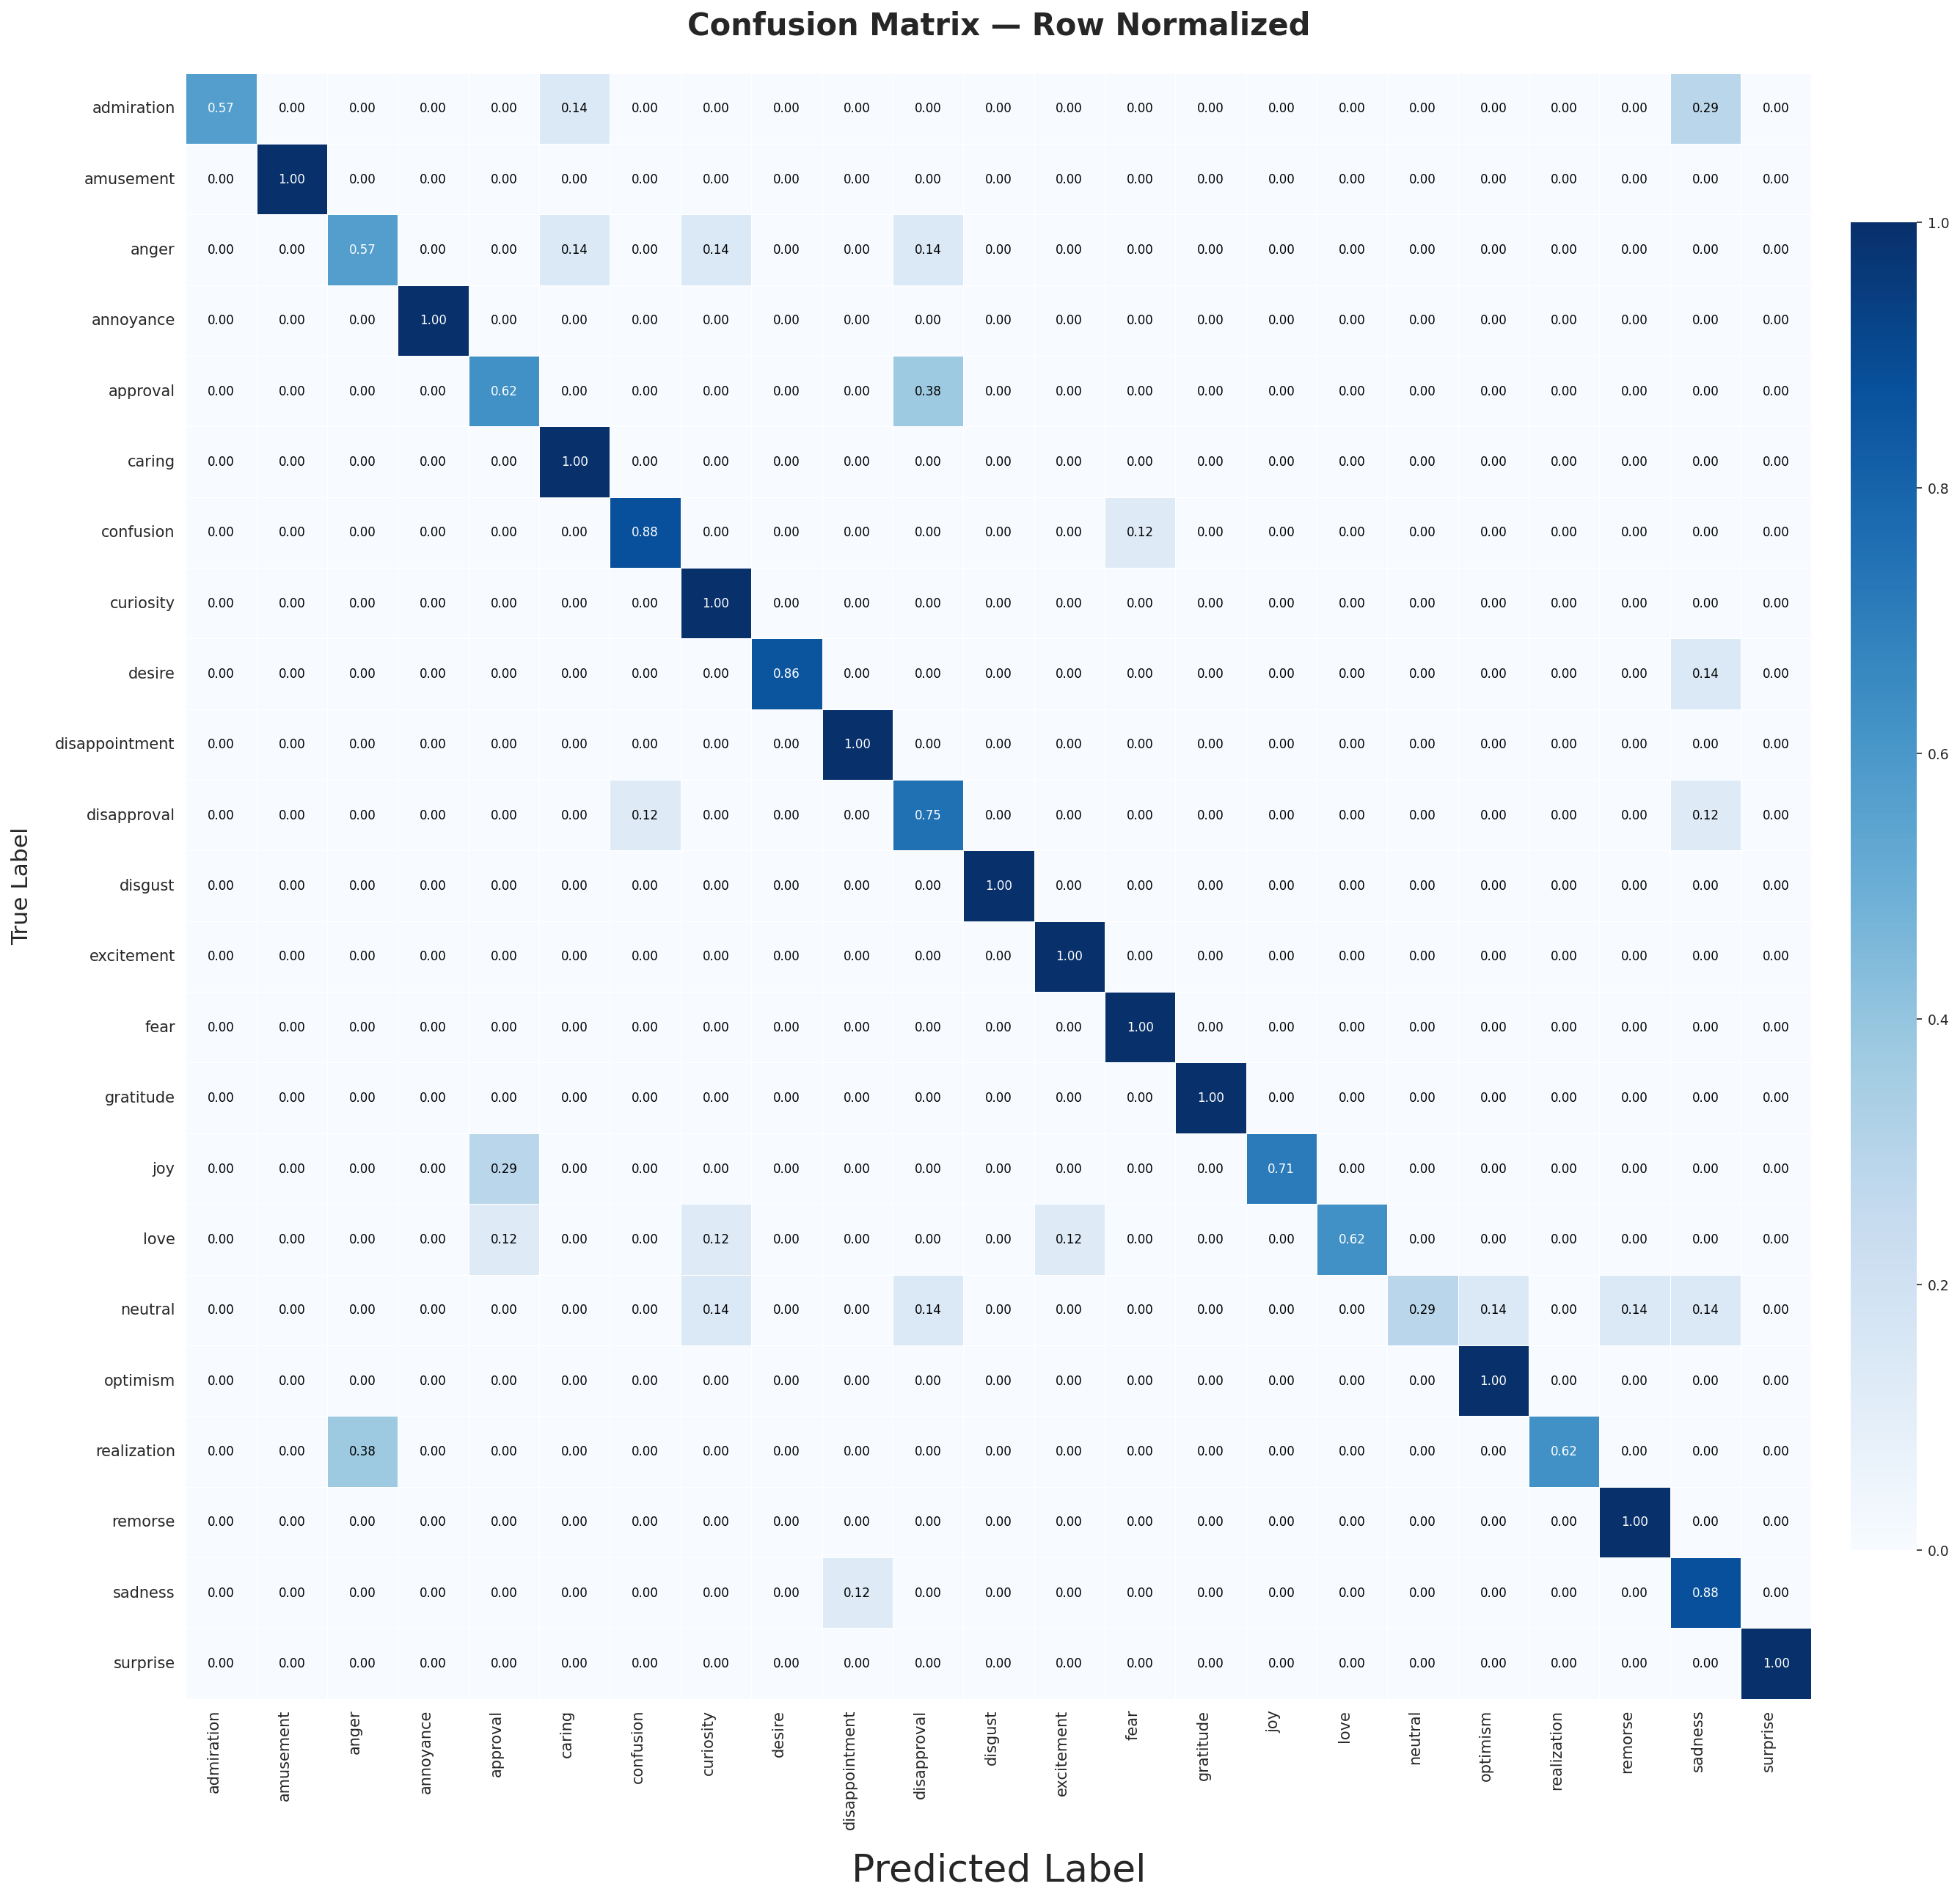

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# COMPUTE MATRICES
# =========================================================
cm   = confusion_matrix(test_y, test_pred)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# =========================================================
# STYLE
# =========================================================
sns.set_style("white")
plt.rcParams["font.family"] = "DejaVu Sans"

# =========================================================
# FUNCTION TO DRAW CLEAN HEATMAP
# =========================================================
def draw_confusion_matrix(data,
                          labels,
                          title,
                          fmt,
                          save_path,
                          threshold=None):

    fig, ax = plt.subplots(figsize=(20, 18))

    # Main heatmap
    hm = sns.heatmap(
        data,
        cmap="Blues",
        square=True,
        linewidths=0.4,
        linecolor="white",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
        annot=False,
        cbar_kws={
            "shrink": 0.75,
            "pad": 0.02
        }
    )

    # =====================================================
    # SMART ANNOTATIONS
    # =====================================================
    max_val = data.max()

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):

            val = data[i, j]

            # Skip tiny values to reduce clutter
            if threshold is not None and val < threshold:
                continue

            # Dynamic text color
            color = "white" if val > max_val * 0.5 else "black"

            ax.text(
                j + 0.5,
                i + 0.5,
                format(val, fmt),
                ha="center",
                va="center",
                fontsize=8,
                color=color
            )

    # =====================================================
    # LABELS & TITLES
    # =====================================================
    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        pad=25
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=25,
        labelpad=15
    )

    ax.set_ylabel(
        "True Label",
        fontsize=15,
        labelpad=15
    )

    # Cleaner tick labels
    plt.xticks(
        rotation=90,
        ha="right",
        fontsize=10
    )

    plt.yticks(
        rotation=0,
        fontsize=10
    )

    # Add padding around figure
    plt.tight_layout(pad=2)

    # Save
    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# RAW COUNTS
# =========================================================
draw_confusion_matrix(
    data=cm,
    labels=target_names,
    title="Confusion Matrix — Raw Counts",
    fmt="d",
    save_path=f"{FIG_DIR}/confusion_matrix_raw.png",
    # threshold=1      # hide zeros
)

# =========================================================
# NORMALIZED
# =========================================================
draw_confusion_matrix(
    data=cm_n,
    labels=target_names,
    title="Confusion Matrix — Row Normalized",
    fmt=".2f",
    save_path=f"{FIG_DIR}/confusion_matrix_normalized.png",
    # threshold=0.01   # hide tiny values
)

##  C · Per-Class Metrics — Precision / Recall / F1

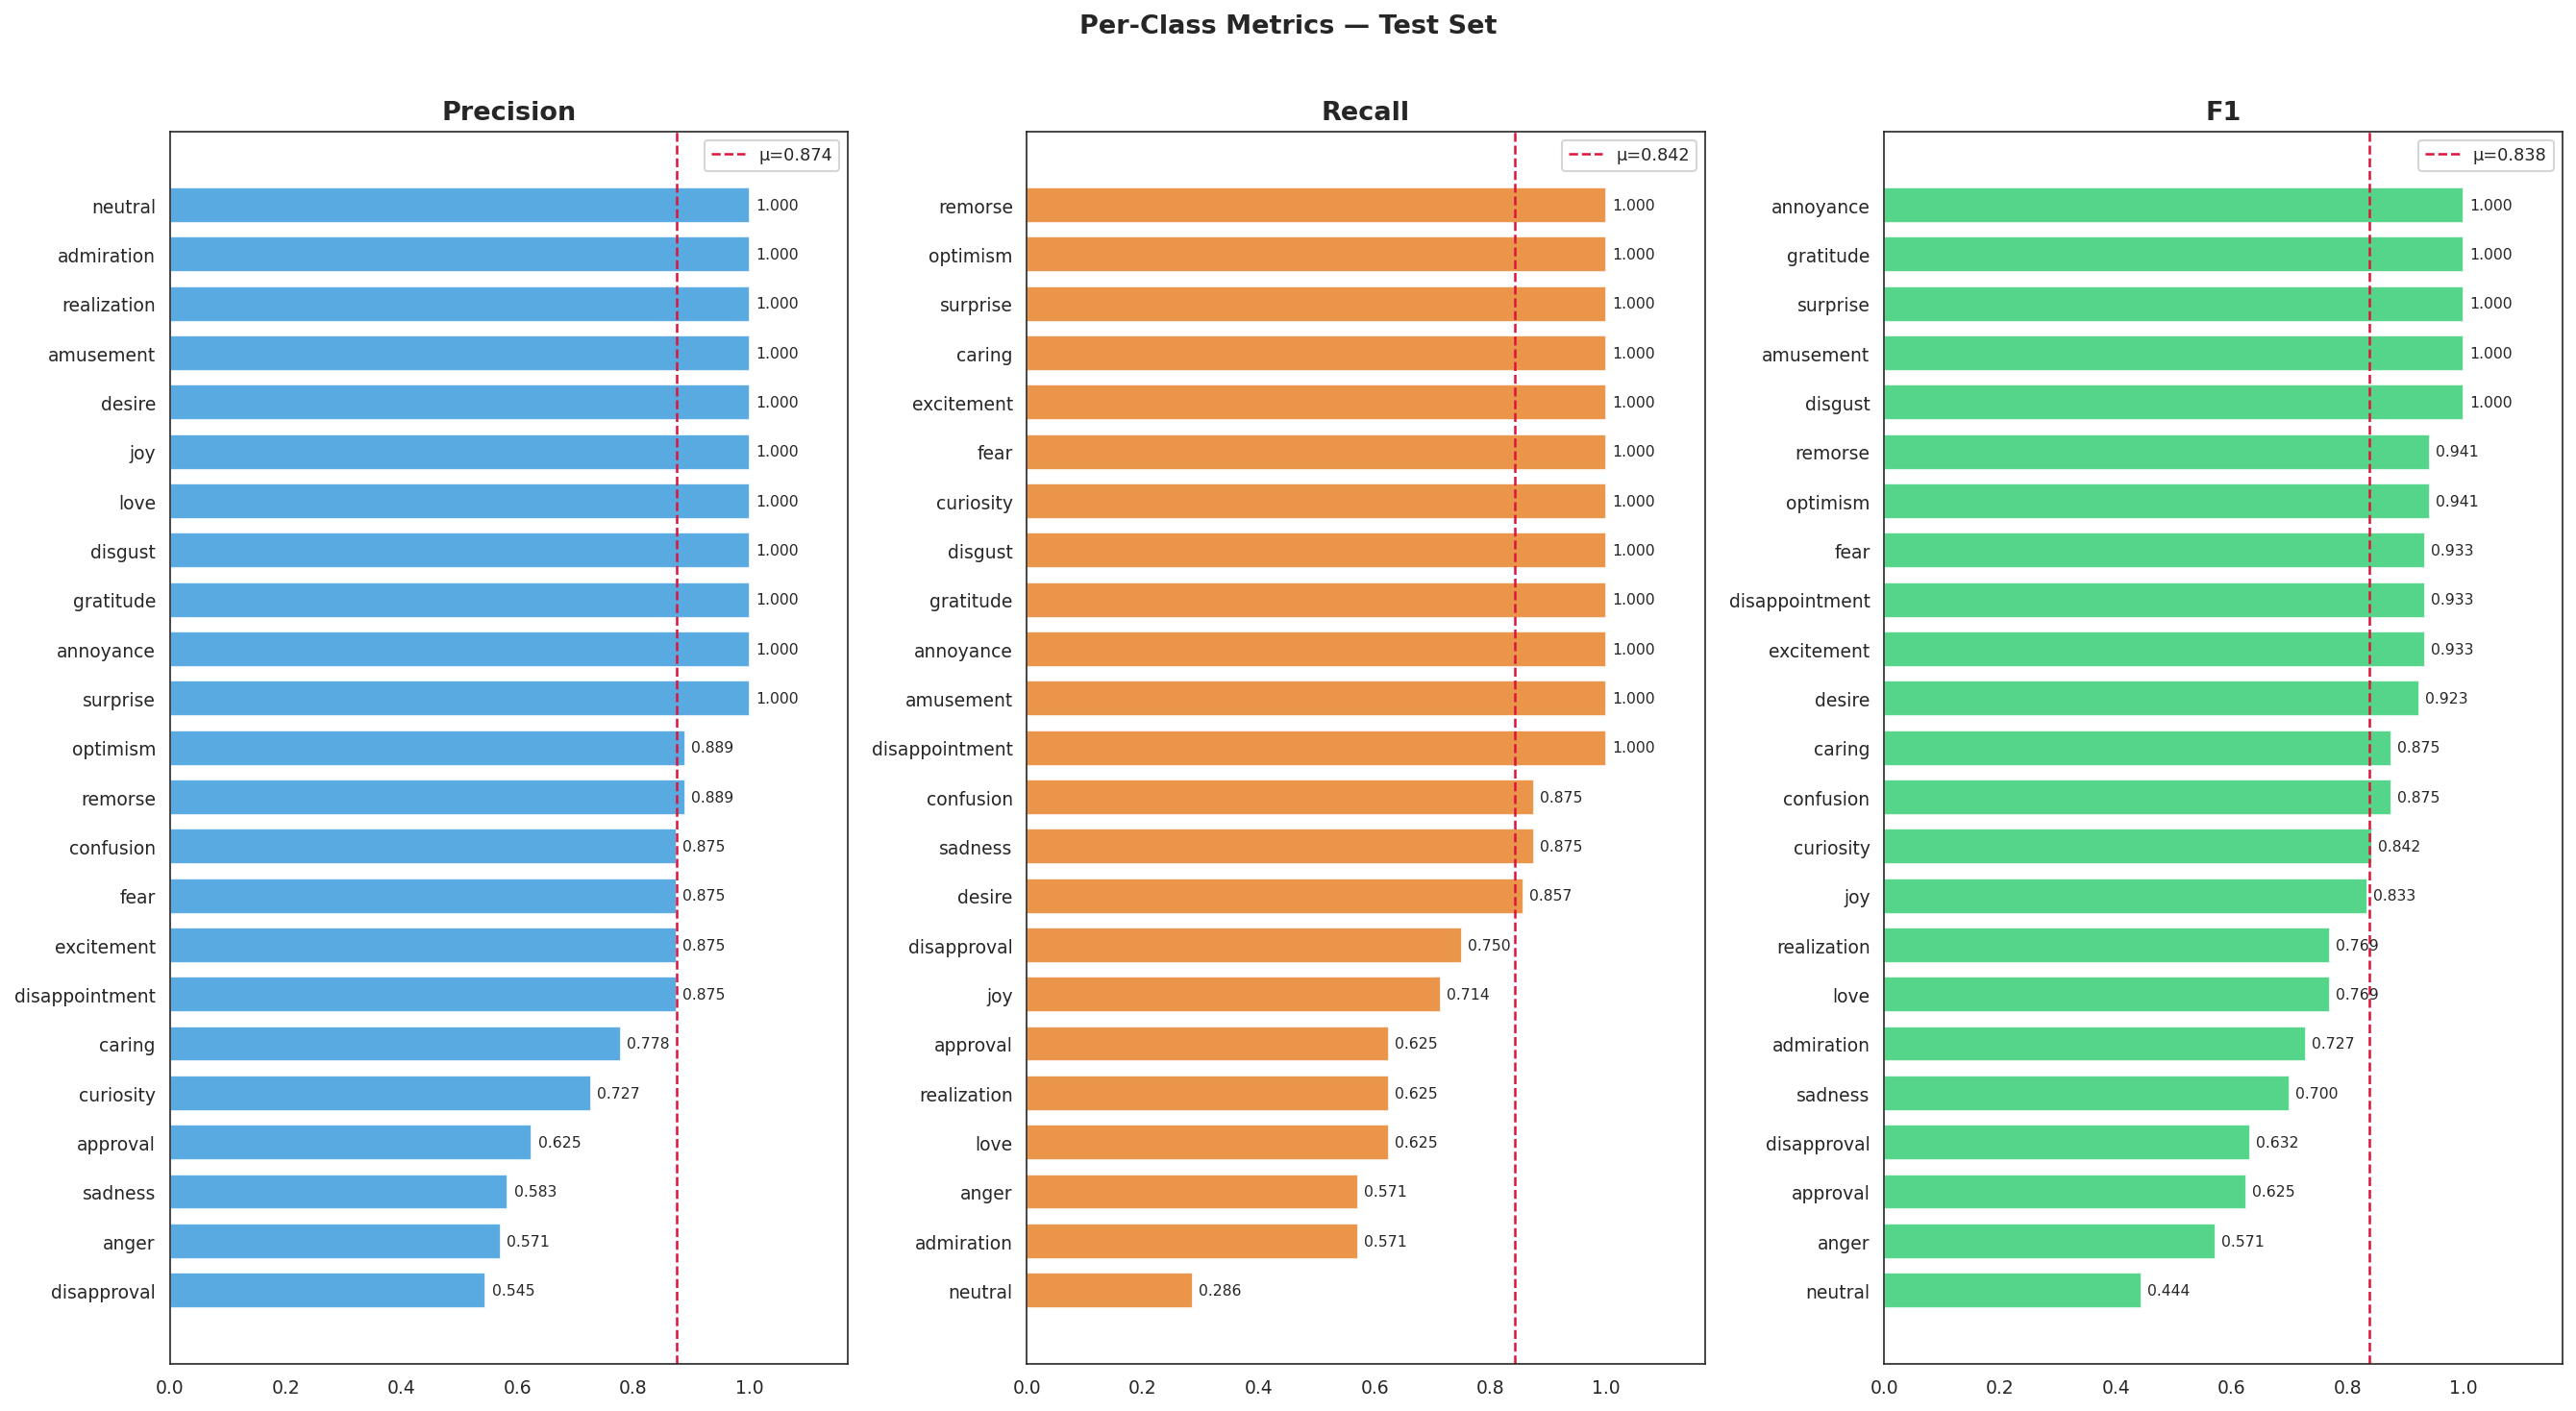

       Emotion  Precision  Recall     F1  Support
     amusement     1.0000  1.0000 1.0000        7
     annoyance     1.0000  1.0000 1.0000        8
     gratitude     1.0000  1.0000 1.0000        8
       disgust     1.0000  1.0000 1.0000        7
      surprise     1.0000  1.0000 1.0000        8
      optimism     0.8889  1.0000 0.9412        8
       remorse     0.8889  1.0000 0.9412        8
disappointment     0.8750  1.0000 0.9333        7
          fear     0.8750  1.0000 0.9333        7
    excitement     0.8750  1.0000 0.9333        7
        desire     1.0000  0.8571 0.9231        7
        caring     0.7778  1.0000 0.8750        7
     confusion     0.8750  0.8750 0.8750        8
     curiosity     0.7273  1.0000 0.8421        8
           joy     1.0000  0.7143 0.8333        7
          love     1.0000  0.6250 0.7692        8
   realization     1.0000  0.6250 0.7692        8
    admiration     1.0000  0.5714 0.7273        7
       sadness     0.5833  0.8750 0.7000        8


In [ ]:
prec, rec, f1c, sup = precision_recall_fscore_support(
    test_y, test_pred, average=None, labels=list(range(NUM_LABELS)))

metrics_df = pd.DataFrame({
    "Emotion":   [label_map[i] for i in range(NUM_LABELS)],
    "Precision": prec, "Recall": rec, "F1": f1c, "Support": sup,
}).sort_values("F1", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, NUM_LABELS*0.42)))
for ax, metric, color in zip(axes, ["Precision","Recall","F1"],
                              ["#3498db","#e67e22","#2ecc71"]):
    order  = metrics_df.sort_values(metric, ascending=True)
    hbars  = ax.barh(order["Emotion"], order[metric],
                     color=color, alpha=0.82, edgecolor="white", height=0.72)
    ax.bar_label(hbars, fmt="%.3f", padding=3, fontsize=7.5)
    ax.axvline(order[metric].mean(), color="crimson", ls="--", lw=1.2,
               label=f"μ={order[metric].mean():.3f}")
    ax.set(xlim=(0,1.17), title=metric); ax.legend(fontsize=8.5)

plt.suptitle("Per-Class Metrics — Test Set", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/C_per_class_metrics.pdf", bbox_inches="tight")
plt.show()

print(metrics_df.round(4).to_string(index=False))

##  D · Calibration Analysis

### D.1 Expected Calibration Error (ECE)
$$\text{ECE} = \sum_b \frac{|B_b|}{n}\,|\text{acc}(B_b)-\text{conf}(B_b)|$$

### D.2 Temperature Scaling
Post-hoc: divide logits by learned scalar T on validation set.  
T > 1 → model overconfident; T < 1 → model underconfident.

ECE before temperature scaling: 0.0555
Optimal T = 1.0527
ECE  after temperature scaling : 0.0819
ECE  improvement               : -0.0264


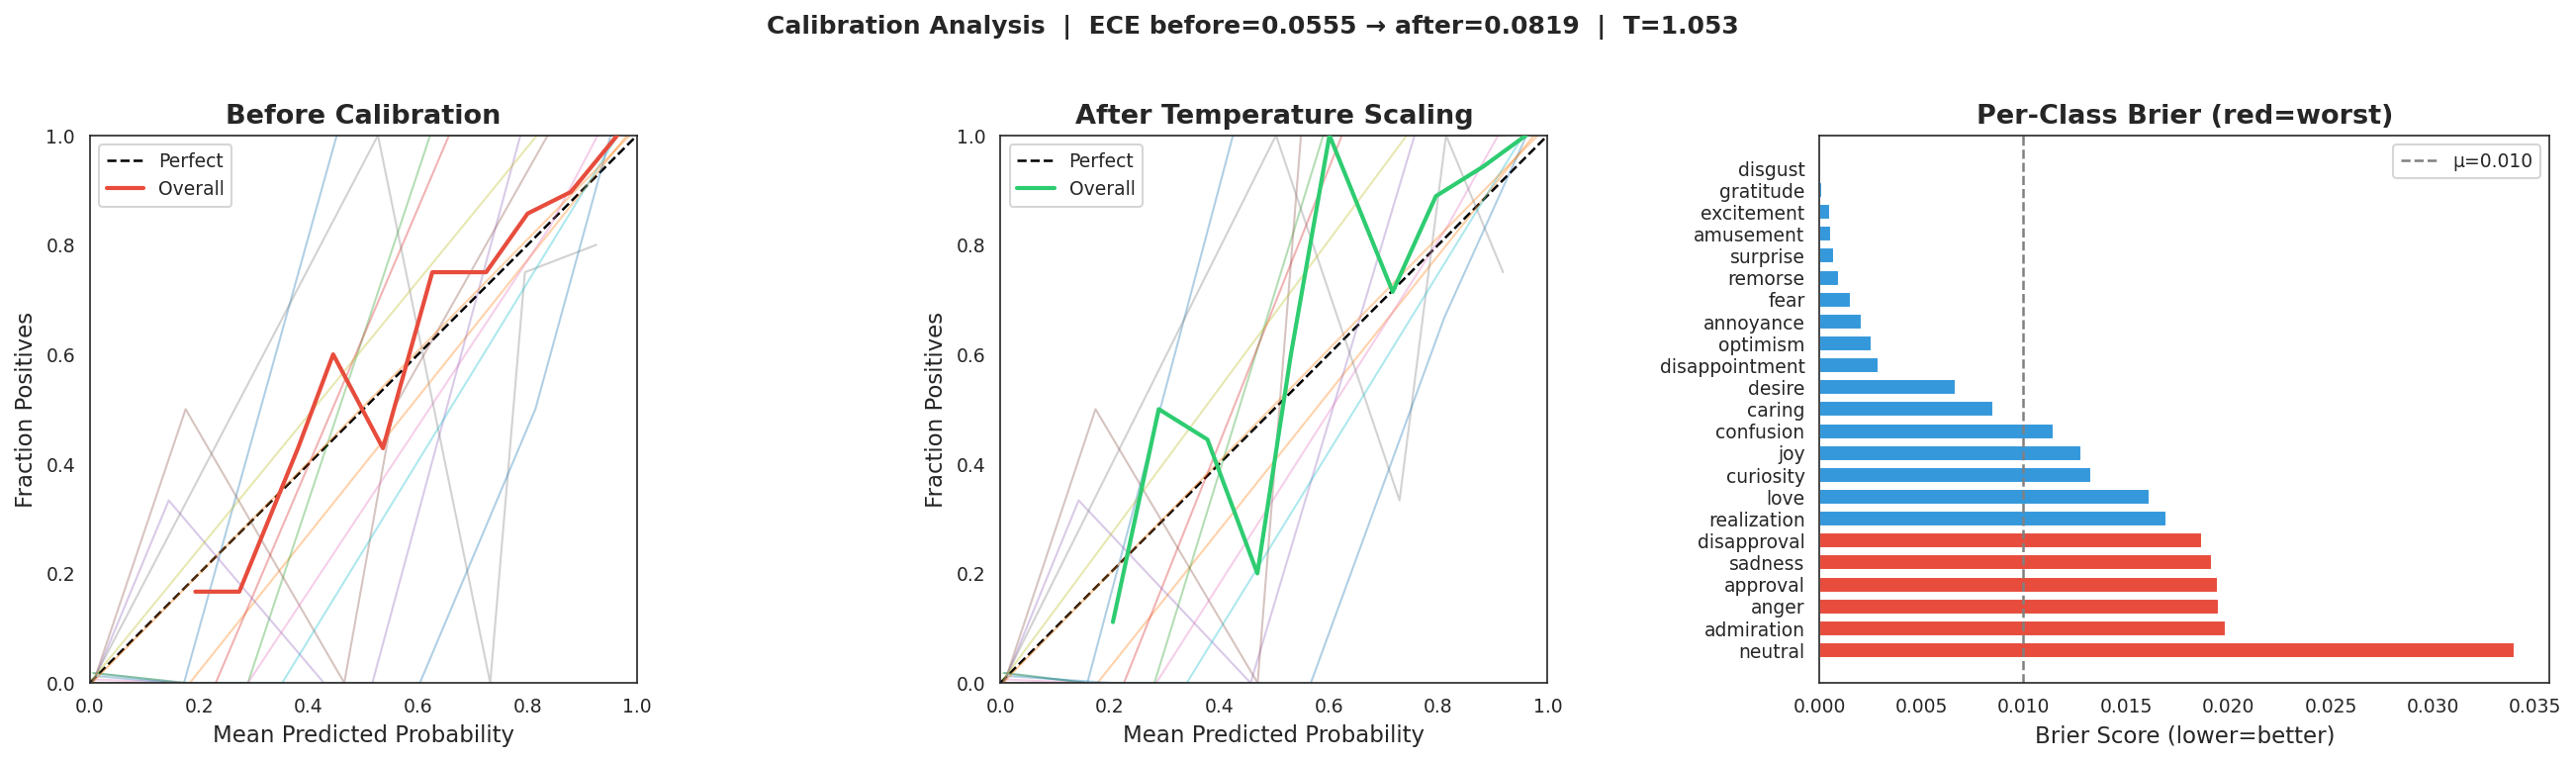

In [ ]:
# ── D.1 ECE ───────────────────────────────────────────────────────────────────
def compute_ece(probs, labels, n_bins=15):
    confs = probs.max(1); preds = probs.argmax(1)
    correct = (preds == labels).astype(float)
    edges   = np.linspace(0, 1, n_bins+1)
    ece     = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (confs >= lo) & (confs < hi)
        if mask.sum() == 0: continue
        ece += mask.mean() * abs(correct[mask].mean() - confs[mask].mean())
    return ece

ece_before = compute_ece(test_probs, test_y)
print(f"ECE before temperature scaling: {ece_before:.4f}")

# ── D.2 Temperature Scaling ───────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        self.T     = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, **kwargs):
        logits = self.model(**kwargs)
        return logits / self.T.clamp(min=0.1)

def fit_temperature(base_model, loader):
    ts = TemperatureScaler(base_model).to(device)
    opt = torch.optim.LBFGS([ts.T], lr=0.01, max_iter=200)
    all_logits, all_labels = [], []
    base_model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = move(batch)
            with autocast(device_type=DEVICE_STR):
                logits = base_model(
                    ctg_ids=batch["ctg_ids"], ctg_len=batch["ctg_len"],
                    ctg_bl_ids=batch["ctg_bl_ids"], ctg_bl_len=batch["ctg_bl_len"],
                    bb_input_ids=batch["bb_input_ids"], bb_mask=batch["bb_mask"],
                    rb_input_ids=batch["rb_input_ids"], rb_mask=batch["rb_mask"],
                )
            all_logits.append(logits.float()); all_labels.append(batch["labels"])
    lc = torch.cat(all_logits); yc = torch.cat(all_labels)
    def nll():
        opt.zero_grad()
        loss = F.cross_entropy(lc / ts.T.clamp(min=0.1), yc)
        loss.backward()  # FIX 1: plain backward — LBFGS is incompatible with GradScaler
        return loss
    opt.step(nll)
    print(f"Optimal T = {ts.T.item():.4f}")
    return ts, ts.T.item()

ts_model, T_opt = fit_temperature(model, val_loader)

# Calibrated test probabilities
cal_probs = []
ts_model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = move(batch)
        with autocast(device_type=DEVICE_STR):
            logits = ts_model(
                ctg_ids=batch["ctg_ids"], ctg_len=batch["ctg_len"],
                ctg_bl_ids=batch["ctg_bl_ids"], ctg_bl_len=batch["ctg_bl_len"],
                bb_input_ids=batch["bb_input_ids"], bb_mask=batch["bb_mask"],
                rb_input_ids=batch["rb_input_ids"], rb_mask=batch["rb_mask"],
            )
        cal_probs.extend(F.softmax(logits.float(), dim=1).cpu().numpy())
cal_probs = np.array(cal_probs)

ece_after = compute_ece(cal_probs, test_y)
print(f"ECE  after temperature scaling : {ece_after:.4f}")
print(f"ECE  improvement               : {ece_before-ece_after:.4f}")

# ── D.3 Reliability Diagram + Brier ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reliability diagram — before & after
for probs_set, ax, title, c in [
    (test_probs, axes[0], "Before Calibration", "#e74c3c"),
    (cal_probs,  axes[1], "After Temperature Scaling", "#2ecc71")]:
    ax.plot([0,1],[0,1],"k--",lw=1.2,label="Perfect")
    for i in range(0, min(NUM_LABELS,12)):
        bl = (test_y==i).astype(int)
        if bl.sum()<5: continue
        fp, mp = calibration_curve(bl, probs_set[:,i], n_bins=8)
        ax.plot(mp, fp, alpha=0.35, lw=1)
    # Overall max-class reliability
    confs_all  = probs_set.max(1)
    correct_all= (probs_set.argmax(1)==test_y).astype(int)
    fp_all, mp_all = calibration_curve(correct_all, confs_all, n_bins=12)
    ax.plot(mp_all, fp_all, c, lw=2, label="Overall", zorder=5)
    ax.set(xlabel="Mean Predicted Probability", ylabel="Fraction Positives",
           title=title, xlim=(0,1), ylim=(0,1))
    ax.legend(); ax.set_aspect("equal")

# Brier scores per class
brier = {label_map[i]: brier_score_loss((test_y==i).astype(int), cal_probs[:,i])
         for i in range(NUM_LABELS)}
bdf   = pd.Series(brier).sort_values(ascending=False)
colors_b = ["#e74c3c" if v > np.percentile(list(brier.values()),75) else
            "#3498db" for v in bdf.values]
axes[2].barh(bdf.index, bdf.values, color=colors_b, edgecolor="white", height=0.72)
axes[2].axvline(bdf.mean(), color="gray", ls="--", lw=1.2,
                label=f"μ={bdf.mean():.3f}")
axes[2].set(xlabel="Brier Score (lower=better)",
            title="Per-Class Brier (red=worst)")
axes[2].legend()

plt.suptitle(f"Calibration Analysis  |  ECE before={ece_before:.4f} → after={ece_after:.4f}  |  T={T_opt:.3f}",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/D_calibration.pdf", bbox_inches="tight")
plt.show()

## E · SHAP Explainability — Per-Branch Token Attribution

We explain one branch at a time by varying that column's text while holding
all other columns fixed to the case-study values. `shap.Explainer` with a
word-level `Text` masker returns Shapley values for each token's contribution
to every output class. We then plot the top predicted class.

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-noto-core

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-noto-core
0 upgraded, 1 newly installed, 0 to remove and 107 not upgraded.
Need to get 12.2 MB of archives.
After this operation, 43.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Fetched 12.2 MB in 0s (85.3 MB/s)
Selecting previously unselected package fonts-noto-core.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ub

In [ ]:
import matplotlib.font_manager as fm

# Find Bengali fonts
for f in fm.findSystemFonts():
    if "Bengali" in f or "NotoSansBengali" in f:
        print(f)

/usr/share/fonts/truetype/noto/NotoSansBengali-Bold.ttf
/usr/share/fonts/truetype/noto/NotoSerifBengali-Regular.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf
/usr/share/fonts/truetype/noto/NotoSerifBengali-Bold.ttf


Explaining top predicted class: 'desire' (index 8)


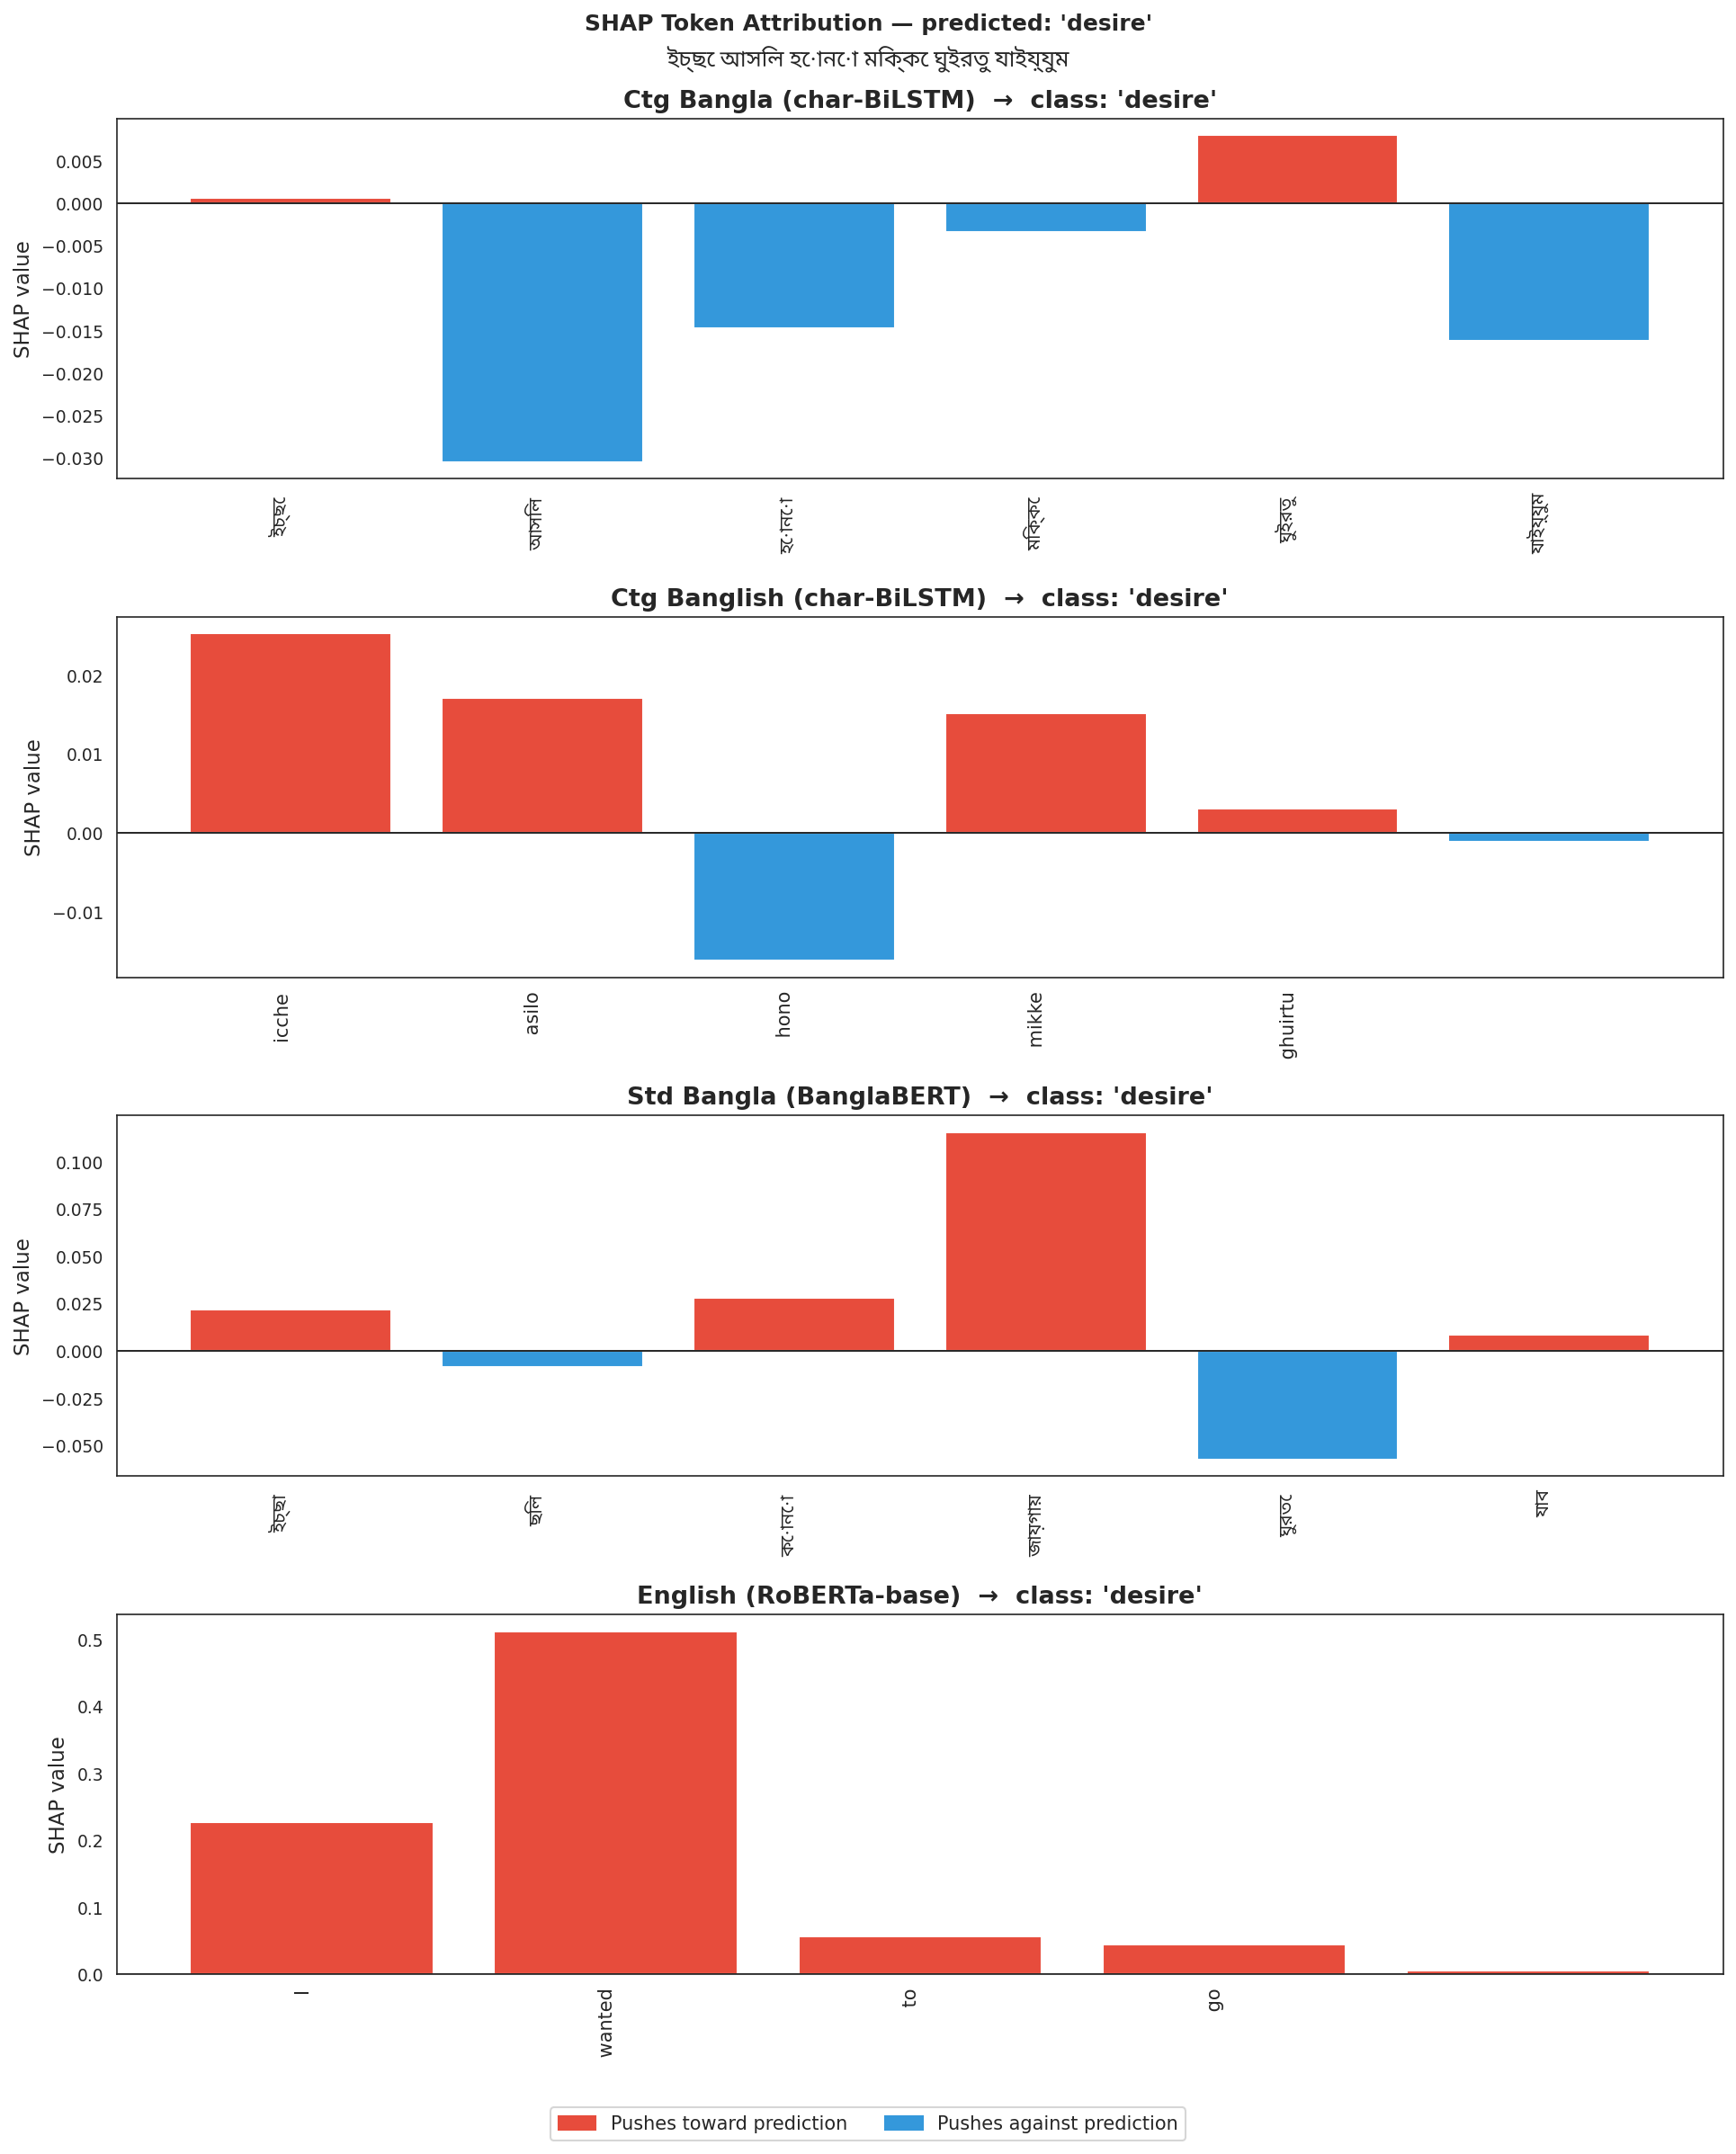

In [ ]:
# ── Install Bengali font (run once; Colab needs this) ─────────────────────────
import subprocess, matplotlib, matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import urllib.request, os

# Download Noto Sans Bengali if not already present
_FONT_PATH = "/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf"
if not os.path.exists(_FONT_PATH):
    os.makedirs(os.path.dirname(_FONT_PATH), exist_ok=True)
    urllib.request.urlretrieve(
        "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/"
        "NotoSansBengali/NotoSansBengali-Regular.ttf",
        _FONT_PATH,
    )
    fm.fontManager.addfont(_FONT_PATH)
    matplotlib.font_manager._load_fontmanager(try_read_cache=False)  # rebuild cache

_bn_font  = FontProperties(fname=_FONT_PATH, size=10)   # Bengali labels
_bn_title = FontProperties(fname=_FONT_PATH, size=12)   # Bengali in suptitle

# ─────────────────────────────────────────────────────────────────────────────
model.eval()

def make_predict_fn(fixed_row, vary_col, tokenizer_for_col=None):
    def predict_fn(texts):
        probs_list = []
        for i in range(0, len(texts), 8):
            chunk = texts[i:i+8]
            rows  = []
            for t in chunk:
                row = dict(fixed_row)
                row[vary_col] = t
                rows.append(row)
            tmp_df    = pd.DataFrame(rows)
            tmp_ds    = FusionDataset(tmp_df, [0]*len(rows), bangla_tok, roberta_tok,
                                      char_vocab, MAX_CHAR_LEN, MAX_SEQ_LEN)
            tmp_batch = move(fusion_collate([tmp_ds[j] for j in range(len(rows))]))
            with torch.no_grad():
                with autocast(device_type=DEVICE_STR):
                    logits = model(
                        ctg_ids=tmp_batch["ctg_ids"],
                        ctg_len=tmp_batch["ctg_len"],
                        ctg_bl_ids=tmp_batch["ctg_bl_ids"],
                        ctg_bl_len=tmp_batch["ctg_bl_len"],
                        bb_input_ids=tmp_batch["bb_input_ids"],
                        bb_mask=tmp_batch["bb_mask"],
                        rb_input_ids=tmp_batch["rb_input_ids"],
                        rb_mask=tmp_batch["rb_mask"],
                    )
            probs_list.append(F.softmax(logits.float(), dim=1).cpu().numpy())
        return np.vstack(probs_list)
    return predict_fn

# Separate maskers per script type
bangla_masker = shap.maskers.Text(r" ")     # whitespace only — preserves ZWJ/nukta
latin_masker  = shap.maskers.Text(r"\S+")  # word boundary — correct for ASCII

top_class = int(case_probs.argmax())
top_name  = label_map[top_class]
print(f"Explaining top predicted class: '{top_name}' (index {top_class})")

shap_results = {}
branch_info  = [
    (COL_CTG_BANGLA,   "Ctg Bangla (char-BiLSTM)",  CASE[COL_CTG_BANGLA],  bangla_masker, True),
    (COL_CTG_BANGLISH, "Ctg Banglish (char-BiLSTM)", CASE[COL_CTG_BANGLISH], latin_masker, False),
    (COL_STD_BANGLA,   "Std Bangla (BanglaBERT)",   CASE[COL_STD_BANGLA],  bangla_masker, True),
    (COL_ENGLISH,      "English (RoBERTa-base)",      CASE[COL_ENGLISH],     latin_masker, False),
]

fig, axes = plt.subplots(len(branch_info), 1,
                         figsize=(13, 4 * len(branch_info)))

# suptitle contains Bengali — split into two Text objects so each gets
# the right font (matplotlib suptitle doesn't support per-character fonts)
fig.text(0.5, 0.98,
         f"SHAP Token Attribution — predicted: '{top_name}'",
         ha="center", va="top", fontsize=12, fontweight="bold")
fig.text(0.5, 0.965,
         "ইচ্ছে আসিল হোনো মিক্কে ঘুইরতু যাইয়্যুম",
         ha="center", va="top", fontproperties=_bn_title)

for ax, (col, title, text, masker, is_bengali) in zip(axes, branch_info):
    pred_fn   = make_predict_fn(CASE, col)
    explainer = shap.Explainer(pred_fn, masker,
                               output_names=target_names,
                               algorithm="permutation",
                               max_evals=256)
    sv = explainer([text])
    shap_results[col] = sv

    words     = list(sv.data[0])          # actual masker tokens (FIX 5)
    sv_class  = sv.values[0, :len(words), top_class]
    colors_sv = ["#e74c3c" if v > 0 else "#3498db" for v in sv_class]

    ax.bar(range(len(words)), sv_class, color=colors_sv, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("SHAP value")
    ax.set_title(title + f"  →  class: '{top_name}'")

    ax.set_xticks(range(len(words)))      # FIX 6: set_xticks before set_xticklabels

    # ── BENGALI FIX: use FontProperties for Bengali tick labels ──────────────
    # matplotlib's default DejaVu Sans has no Bengali glyphs; we must set
    # fontproperties per-label rather than via rcParams so Latin branches
    # continue to use the default font unchanged.
    tick_fp = _bn_font if is_bengali else None
    labels  = ax.set_xticklabels(words, rotation=90, ha="right", fontsize=10)
    if tick_fp is not None:
        for lbl in labels:
            lbl.set_fontproperties(tick_fp)

pos_patch = mpatches.Patch(color="#e74c3c", label="Pushes toward prediction")
neg_patch = mpatches.Patch(color="#3498db", label="Pushes against prediction")
fig.legend(handles=[pos_patch, neg_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.02, 1, 0.955])   # leave room for the two-line title
plt.savefig(f"{FIG_DIR}/E_shap_branches.pdf", bbox_inches="tight")
plt.show()

## F · LIME Explainability — Local Linear Approximation

LIME perturbs the input by randomly masking words, runs the model on each
perturbation, and fits a local linear model to explain the prediction.
We run LIME on the English branch for maximum readability.

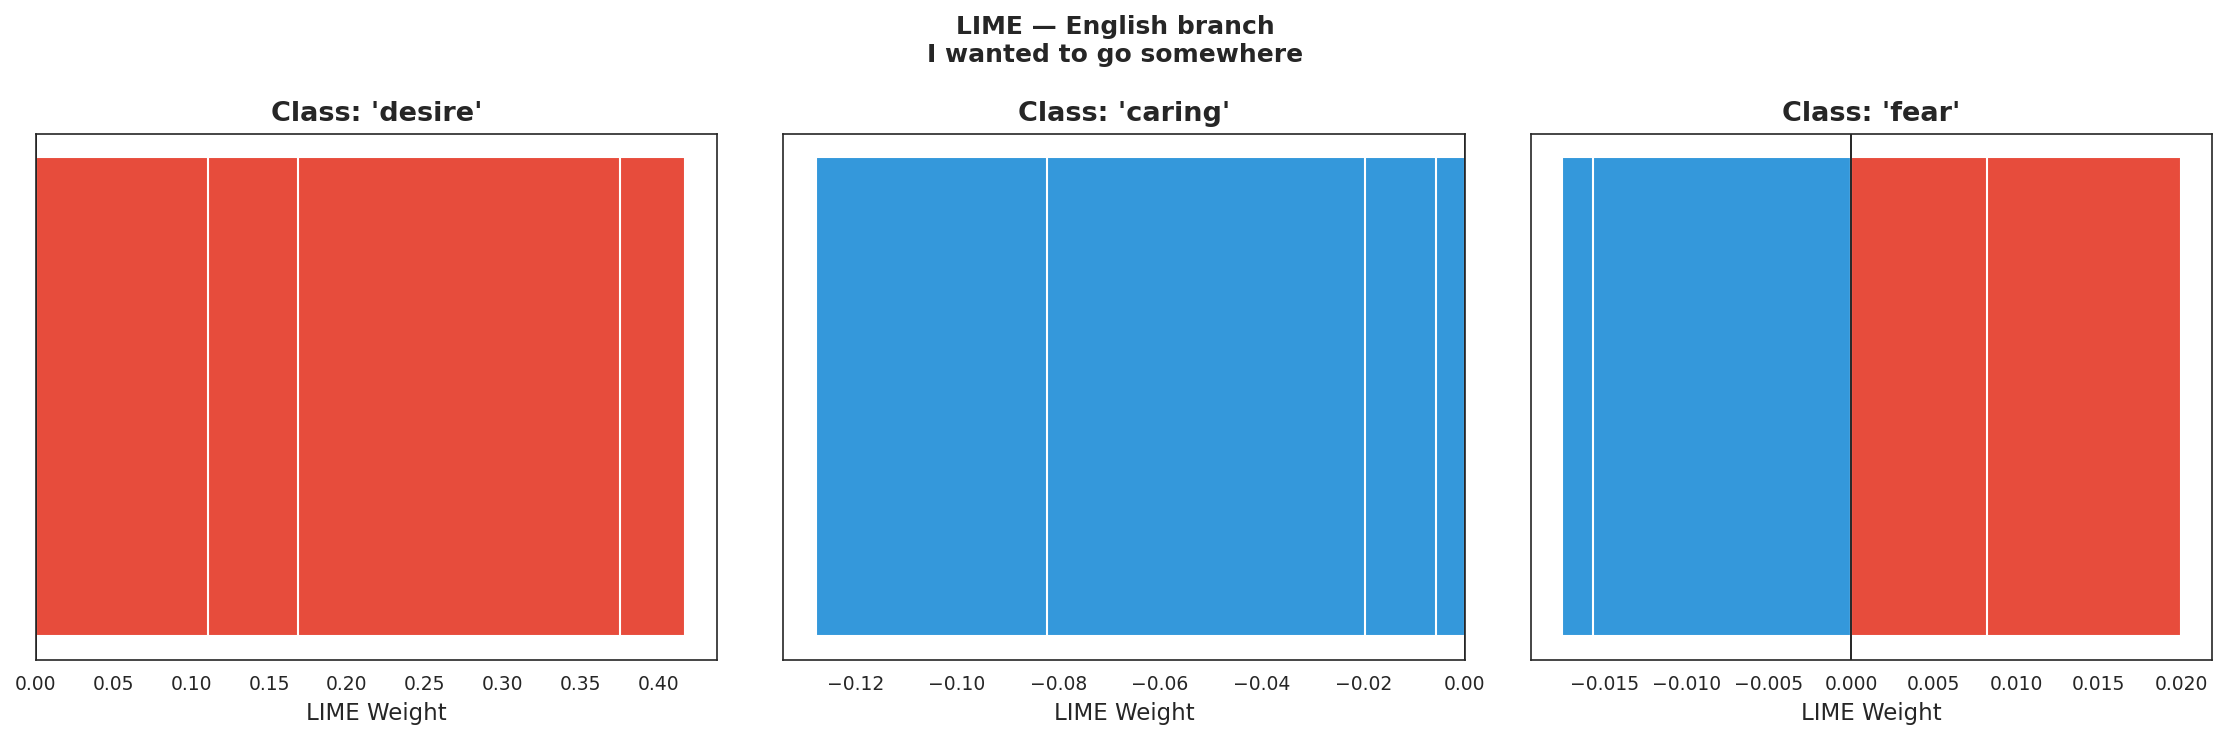

In [ ]:
lime_explainer = LimeTextExplainer(
    class_names  = target_names,
    split_expression = r"\S+",
    bow          = False,
    random_state = SEED,
)

def lime_predict_fn_english(texts):
    """Vary English column, fix all others."""
    return make_predict_fn(CASE, COL_ENGLISH)(texts)

lime_exp = lime_explainer.explain_instance(
    CASE[COL_ENGLISH],
    lime_predict_fn_english,
    num_features  = 10,
    num_samples   = 500,
    top_labels     = 3,
)

# ── Plot LIME explanation for top 3 labels ────────────────────────────────────
# FIX 7: sort by descending predicted probability, not by class index;
# sorted(available_labels()) gives index order (e.g. 1,3,7) which is arbitrary
_avail = set(lime_exp.available_labels())
top3_labels = [int(i) for i in np.argsort(case_probs)[::-1] if int(i) in _avail][:3]
fig, axes   = plt.subplots(1, len(top3_labels), figsize=(5*len(top3_labels), 5))
if len(top3_labels) == 1: axes = [axes]

for ax, lbl in zip(axes, top3_labels):
    feats = lime_exp.as_list(label=lbl)
    words  = [f[0] for f in feats]
    values = [f[1] for f in feats]
    colors_l = ["#e74c3c" if v > 0 else "#3498db" for v in values]
    ax.barh(words, values, color=colors_l, edgecolor="white", height=0.72)
    ax.axvline(0, color="black", lw=0.8)
    ax.set(xlabel="LIME Weight", title=f"Class: '{target_names[lbl]}'")
    ax.invert_yaxis()

plt.suptitle(f"LIME — English branch\n{CASE[COL_ENGLISH]}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/F_lime_explanation.pdf", bbox_inches="tight")
plt.show()

## G · Ablation Study — Branch Contribution

Each branch is ablated by replacing its projection output with zeros,
leaving all other branches intact. No separate model is needed.

  Full model                      acc=0.8439  macro-F1=0.8378
  − Ctg Bangla                    acc=0.8382  macro-F1=0.8323
  − Ctg Banglish                  acc=0.8439  macro-F1=0.8395
  − Std Bangla                    acc=0.8324  macro-F1=0.8256
  − English                       acc=0.6590  macro-F1=0.6235
  Ctg Bangla only                 acc=0.3353  macro-F1=0.2831
  Ctg Banglish only               acc=0.1676  macro-F1=0.1345
  Std Bangla only                 acc=0.5838  macro-F1=0.5265
  English only                    acc=0.7746  macro-F1=0.7747
  Char branches only              acc=0.3237  macro-F1=0.2827
  Transformer only                acc=0.8382  macro-F1=0.8335


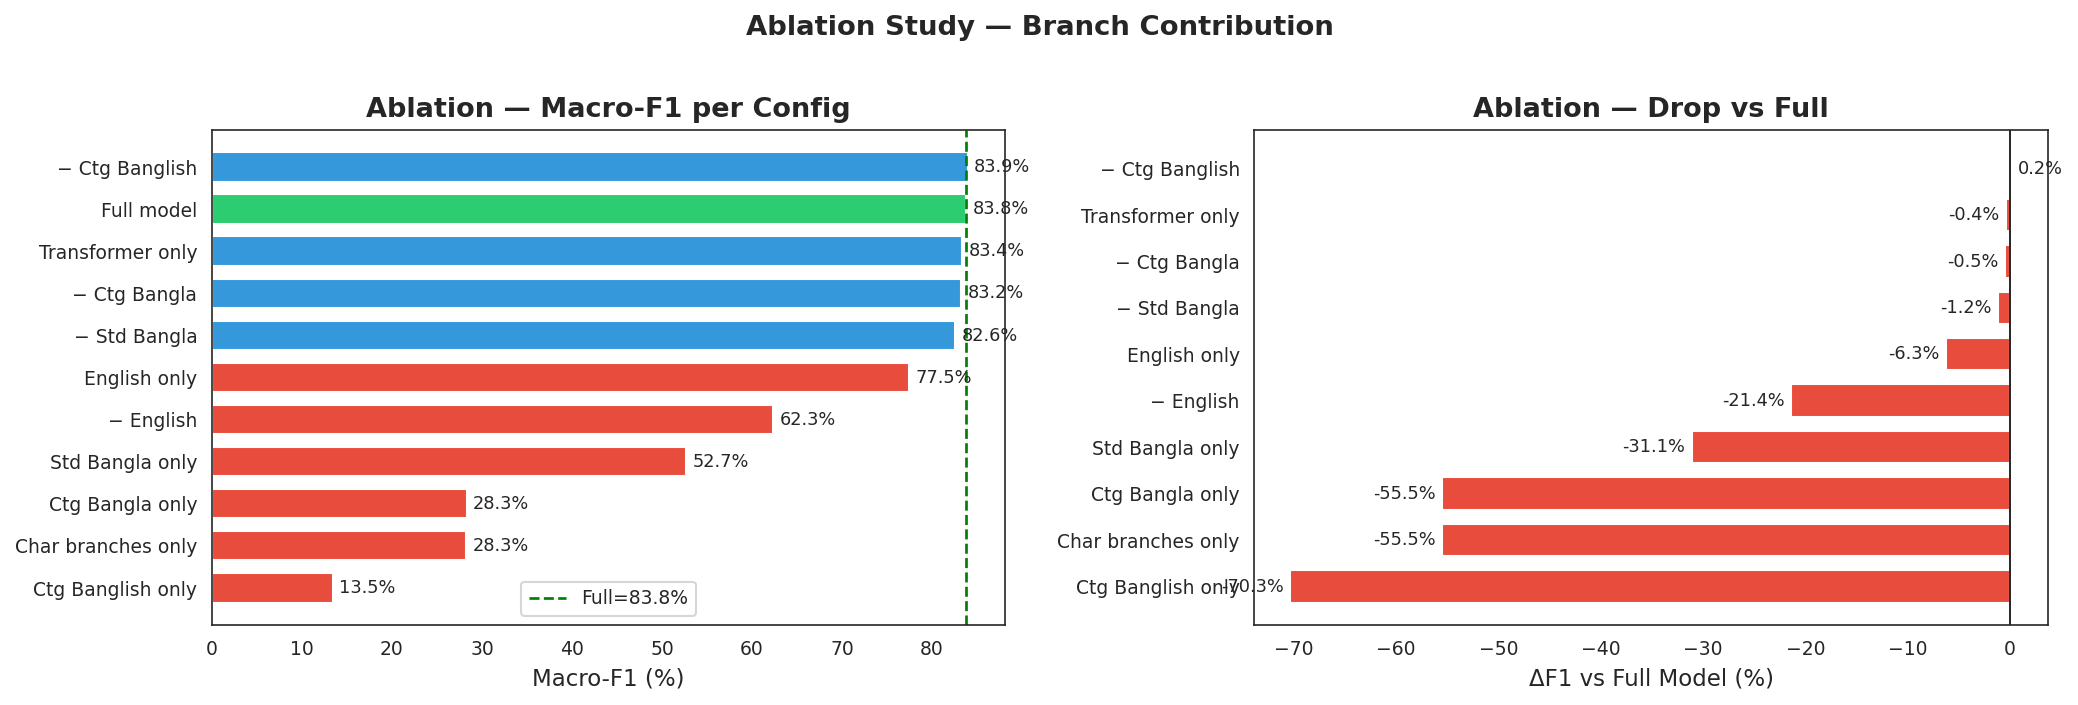

In [ ]:
ablation_configs = {
    "Full model":             set(),
    "− Ctg Bangla":          {"ctg"},
    "− Ctg Banglish":        {"banglish"},
    "− Std Bangla":          {"bangla"},
    "− English":             {"english"},
    "Ctg Bangla only":       {"banglish","bangla","english"},
    "Ctg Banglish only":     {"ctg","bangla","english"},
    "Std Bangla only":       {"ctg","banglish","english"},
    "English only":          {"ctg","banglish","bangla"},
    "Char branches only":    {"bangla","english"},
    "Transformer only":      {"ctg","banglish"},
}

ablation_results = {}
for name, ablate_set in ablation_configs.items():
    # FIX 2: removed duplicate evaluate() call; f1_val was silently discarded
    _, acc, f1, *_   = evaluate(model, test_loader, ablate=ablate_set)
    ablation_results[name] = {"acc": acc, "f1": f1}
    print(f"  {name:<30s}  acc={acc:.4f}  macro-F1={f1:.4f}")

# ── Ablation chart ────────────────────────────────────────────────────────────
full_f1 = ablation_results["Full model"]["f1"]
ab_df   = pd.DataFrame(ablation_results).T.reset_index()
ab_df.columns = ["Config","acc","f1"]
ab_df["delta"] = ab_df["f1"] - full_f1
ab_df = ab_df.sort_values("f1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(ab_df)*0.42)))
# F1 bar
bar_c = ["#2ecc71" if r["Config"]=="Full model" else
          "#e74c3c" if r["delta"] < -0.05 else "#3498db"
          for _, r in ab_df.iterrows()]
hb = axes[0].barh(ab_df["Config"], ab_df["f1"]*100,
                  color=bar_c, edgecolor="white", height=0.7)
axes[0].bar_label(hb, fmt="%.1f%%", padding=3, fontsize=8.5)
axes[0].axvline(full_f1*100, color="green", ls="--", lw=1.3,
                label=f"Full={full_f1*100:.1f}%")
axes[0].set(xlabel="Macro-F1 (%)", title="Ablation — Macro-F1 per Config")
axes[0].legend()

# Delta bar
ab_df2 = ab_df[ab_df["Config"]!="Full model"].copy()
dc = ["#e74c3c" if d < 0 else "#2ecc71" for d in ab_df2["delta"]]
hb2 = axes[1].barh(ab_df2["Config"], ab_df2["delta"]*100,
                   color=dc, edgecolor="white", height=0.7)
axes[1].bar_label(hb2, fmt="%.1f%%", padding=3, fontsize=8.5)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set(xlabel="ΔF1 vs Full Model (%)", title="Ablation — Drop vs Full")

plt.suptitle("Ablation Study — Branch Contribution", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/G_ablation.pdf", bbox_inches="tight")
plt.show()

## H · Error Analysis — 3-Type Taxonomy

| Type | Name | Description |
|---|---|---|
| **I** | Dialect Morphology | Ctg suffix changes emotion; model missed it |
| **II** | Semantic Proximity | Inherently ambiguous label pairs (GoEmotions overlap) |
| **III** | Distribution Shift | Model trained on uniform50, natural speech is skewed |

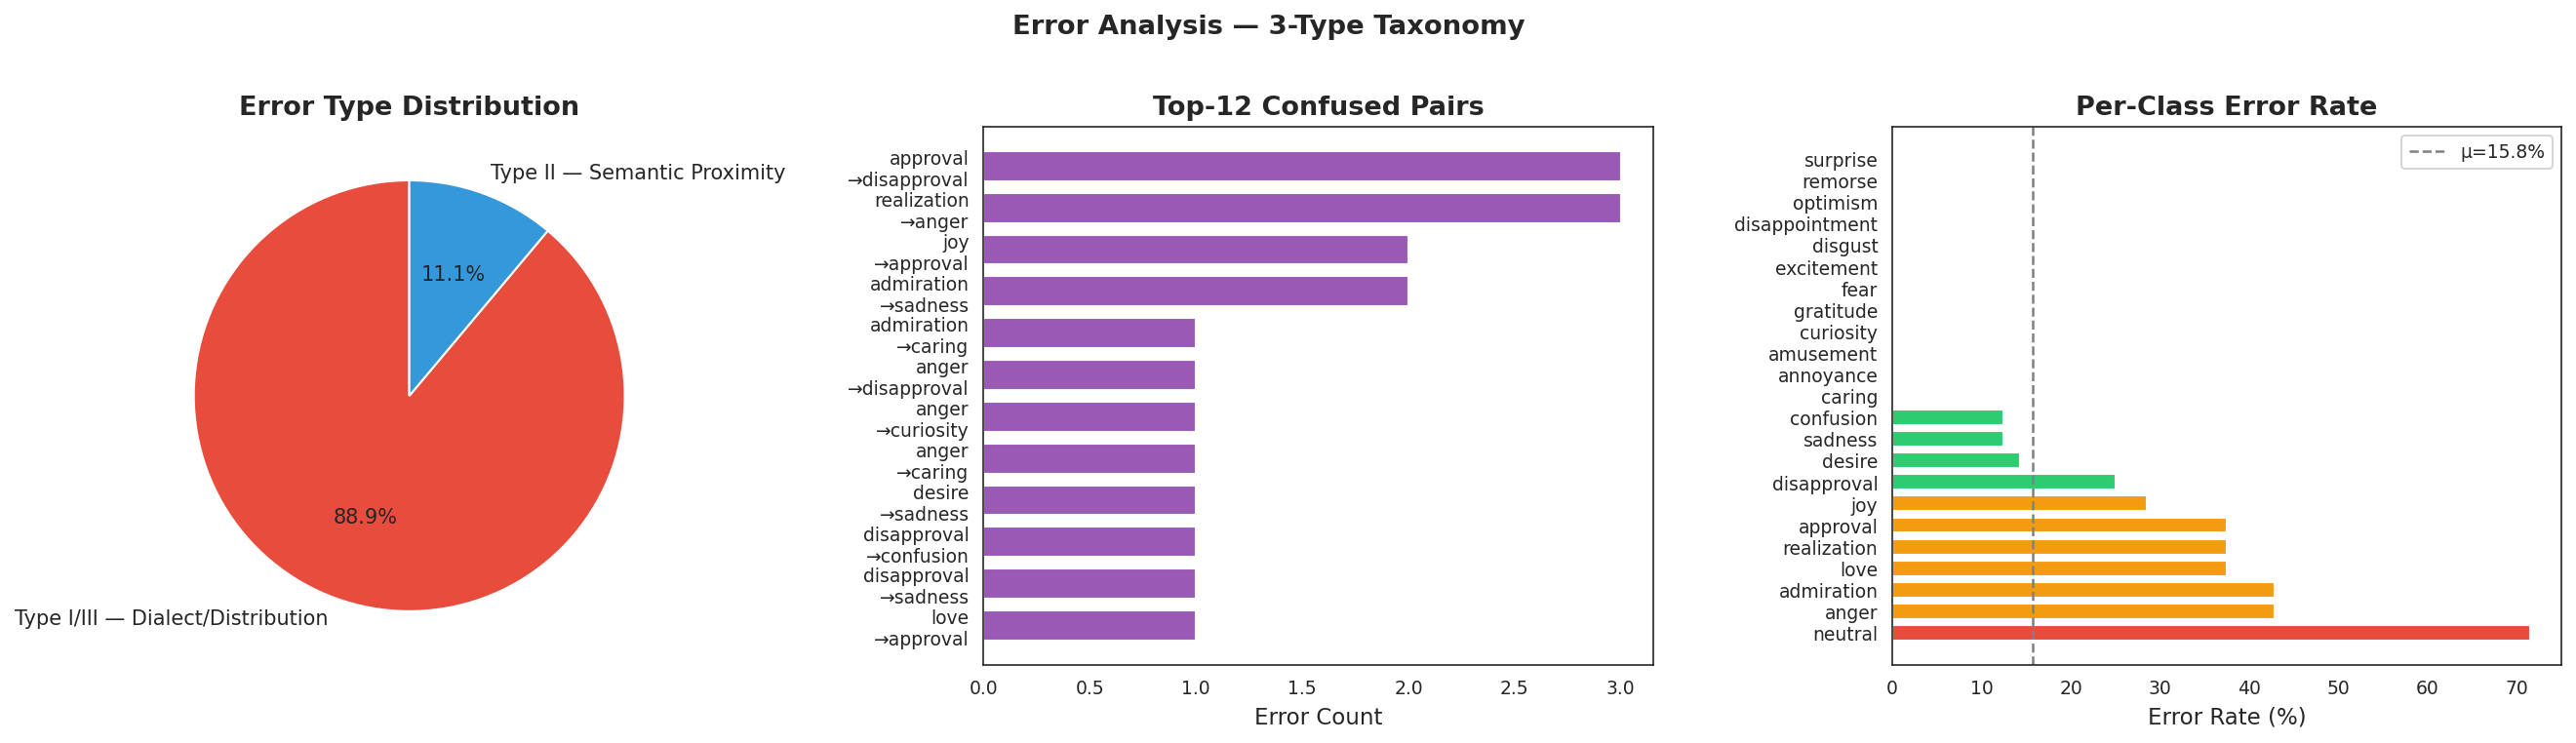

Total errors    : 27 / 173
Overall accuracy: 0.8439

Error type breakdown:
etype
Type I/III — Dialect/Distribution    24
Type II — Semantic Proximity          3


In [ ]:
# ── Semantic proximity groups (annotated manually from GoEmotions paper) ───────
PROXIMITY_GROUPS = [
    {"desire", "optimism", "excitement"},
    {"caring", "love", "admiration"},
    {"curiosity", "realization", "surprise"},
    {"anger", "annoyance", "disapproval"},
    {"sadness", "remorse", "disappointment"},
    {"joy", "amusement", "gratitude"},
]

def error_type(true_lbl, pred_lbl):
    """Classify a single error into Type I, II, or III."""
    for grp in PROXIMITY_GROUPS:
        if true_lbl in grp and pred_lbl in grp:
            return "Type II — Semantic Proximity"
    return "Type I/III — Dialect/Distribution"

# Only look at errors
errors = [(test_y[i], test_pred[i]) for i in range(len(test_y)) if test_y[i] != test_pred[i]]
err_df = pd.DataFrame(errors, columns=["true","pred"])
err_df["true_lbl"] = err_df["true"].map(label_map)
err_df["pred_lbl"] = err_df["pred"].map(label_map)
err_df["etype"]    = err_df.apply(lambda r: error_type(r.true_lbl, r.pred_lbl), axis=1)

# ── Visualise error types ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error type pie
type_counts = err_df["etype"].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index,
            colors=["#e74c3c","#3498db"], autopct="%.1f%%",
            startangle=90, textprops={"fontsize":10})
axes[0].set_title("Error Type Distribution")

# Most confused pairs
pair_counts = err_df.groupby(["true_lbl","pred_lbl"]).size().reset_index(name="count")
pair_counts = pair_counts.sort_values("count", ascending=False).head(12)
pair_counts["pair"] = pair_counts["true_lbl"]+"\n→"+pair_counts["pred_lbl"]
axes[1].barh(pair_counts["pair"][::-1], pair_counts["count"][::-1],
             color="#9b59b6", edgecolor="white", height=0.72)
axes[1].set(xlabel="Error Count", title="Top-12 Confused Pairs")

# Per-class error rate
err_rate = {}
for i in range(NUM_LABELS):
    mask = test_y == i
    if mask.sum() == 0: continue
    err_rate[label_map[i]] = (test_pred[mask] != test_y[mask]).mean()
er_df = pd.Series(err_rate).sort_values(ascending=False)
c_err = ["#e74c3c" if v>0.5 else "#f39c12" if v>0.25 else "#2ecc71" for v in er_df.values]
axes[2].barh(er_df.index, er_df.values*100, color=c_err, edgecolor="white", height=0.72)
axes[2].set(xlabel="Error Rate (%)", title="Per-Class Error Rate")
axes[2].axvline(er_df.mean()*100, color="gray", ls="--", lw=1.2,
                label=f"μ={er_df.mean()*100:.1f}%")
axes[2].legend()

plt.suptitle("Error Analysis — 3-Type Taxonomy", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/H_error_analysis.pdf", bbox_inches="tight")
plt.show()

print(f"Total errors    : {len(errors)} / {len(test_y)}")
print(f"Overall accuracy: {1 - len(errors)/len(test_y):.4f}")
print("\nError type breakdown:")
print(err_df["etype"].value_counts().to_string())

##  I · McNemar's Significance Test

Tests whether the full model is statistically significantly better than each
ablated version. Two-tailed McNemar with exact binomial is standard for
EMNLP model comparison.

McNemar vs Full Model:

  − Ctg Bangla                    b=  2  c=  1  p=1.0000  n.s.
  − Ctg Banglish                  b=0 c=0  p=N/A  (identical)
  − Std Bangla                    b=  4  c=  2  p=0.6875  n.s.
  − English                       b= 33  c=  1  p=0.0000  ✓ sig (p<0.05)
  Ctg Bangla only                 b= 90  c=  2  p=0.0000  ✓ sig (p<0.05)
  Ctg Banglish only               b=118  c=  1  p=0.0000  ✓ sig (p<0.05)
  Std Bangla only                 b= 45  c=  0  p=0.0000  ✓ sig (p<0.05)
  English only                    b= 17  c=  5  p=0.0169  ✓ sig (p<0.05)
  Char branches only              b= 91  c=  1  p=0.0000  ✓ sig (p<0.05)
  Transformer only                b=  2  c=  1  p=1.0000  n.s.


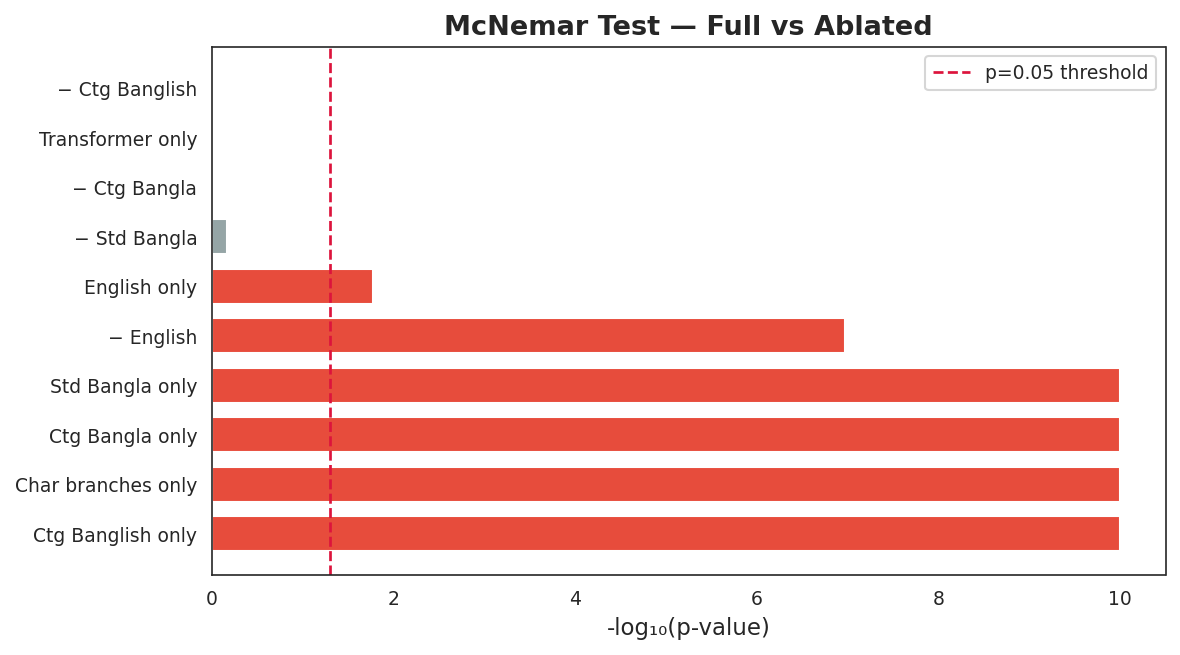

In [ ]:
def run_mcnemar(preds_full, preds_other, true_labels, name):
    ca = (preds_full  == true_labels)
    cb = (preds_other == true_labels)
    b  = int((ca & ~cb).sum())   # full correct, other wrong
    c  = int((~ca & cb).sum())   # full wrong, other correct
    if b+c == 0:
        print(f"  {name:<30s}  b={b} c={c}  p=N/A  (identical)")
        return None
    tbl    = [[0,b],[c,0]]
    result = mcnemar(tbl, exact=(b+c < 25))
    sig    = "✓ sig (p<0.05)" if result.pvalue < 0.05 else "n.s."
    print(f"  {name:<30s}  b={b:3d}  c={c:3d}  p={result.pvalue:.4f}  {sig}")
    return result.pvalue

# Get predictions for each ablation
print("McNemar vs Full Model:\n")
_, _, _, fy, fp, _ = evaluate(model, test_loader, ablate=set())

mcnemar_rows = []
for name, ablate_set in ablation_configs.items():
    if name == "Full model": continue
    _, _, _, ay, ap, _ = evaluate(model, test_loader, ablate=ablate_set)
    p = run_mcnemar(fp, ap, fy, name)
    mcnemar_rows.append({"Config": name, "p-value": p,
                         "significant": p is not None and p < 0.05})

mc_df = pd.DataFrame(mcnemar_rows)

# Visualise p-values
fig, ax = plt.subplots(figsize=(8, max(4, len(mc_df)*0.45)))
# FIX 3: sort FIRST, then build bar_c — original code built colors from unsorted
# mc_df and applied them to sorted bars, causing every color to be misaligned
mc_sorted = mc_df.sort_values("p-value", ascending=True)
bar_c = ["#e74c3c" if r["significant"] else "#95a5a6"
         for _, r in mc_sorted.iterrows()]
# FIX 4: fillna(1.0) before clip — run_mcnemar returns None when b+c==0,
# and pd.Series.clip() raises on None values (NaN is handled but not Python None)
ax.barh(mc_sorted["Config"],
        -np.log10(mc_sorted["p-value"].fillna(1.0).clip(1e-10)),
        color=bar_c, edgecolor="white", height=0.7)
ax.axvline(-np.log10(0.05), color="crimson", ls="--", lw=1.3,
           label="p=0.05 threshold")
ax.set(xlabel="-log₁₀(p-value)", title="McNemar Test — Full vs Ablated")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/I_mcnemar.pdf", bbox_inches="tight")
plt.show()

## J · Expandability

### J.1 — Add a new emotion class (zero backbone retraining)
### J.2 — Add a fifth language branch (structural modularity)

In [ ]:
# ── J.1  Expand to 24 classes ─────────────────────────────────────────────────
import copy

def expand_model_classes(model, n_new=1):
    """Grow final Linear layer by n_new classes, copy existing weights."""
    old_linear = model.head[-1]
    old_out, in_dim = old_linear.out_features, old_linear.in_features
    new_linear = nn.Linear(in_dim, old_out + n_new).to(device)
    with torch.no_grad():
        new_linear.weight[:old_out] = old_linear.weight
        new_linear.bias[:old_out]   = old_linear.bias
        nn.init.normal_(new_linear.weight[old_out:], std=0.02)
        nn.init.zeros_(new_linear.bias[old_out:])
    model.head[-1] = new_linear
    # Freeze everything except the head
    for name, p in model.named_parameters():
        p.requires_grad = "head" in name
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Expanded: {old_out} → {old_out+n_new} classes")
    print(f"  Trainable params (head only): {trainable:,}")
    return model

expanded = copy.deepcopy(model)
expanded = expand_model_classes(expanded, n_new=1)   # e.g. add 'contempt'

# ── J.2  Fifth branch stub ────────────────────────────────────────────────────
print("\nJ.2 — Fifth branch (Arabic) stub:")
print("""
To add a fifth branch:
  1. Load: self.arabert = AutoModel.from_pretrained('aubmindlab/bert-base-arabertv02')
  2. Add:  self.proj_ar = nn.Sequential(LayerNorm(768), Linear(768,256), GELU())
  3. Expand fused_dim to 1280 (5 × 256)
  4. Update head input: Linear(1280, 512)
  5. Freeze original 4 branches, train only proj_ar + head
All original branch weights remain exactly unchanged.
""")

  Expanded: 23 → 24 classes
  Trainable params (head only): 539,160

J.2 — Fifth branch (Arabic) stub:

To add a fifth branch:
  1. Load: self.arabert = AutoModel.from_pretrained('aubmindlab/bert-base-arabertv02')
  2. Add:  self.proj_ar = nn.Sequential(LayerNorm(768), Linear(768,256), GELU())
  3. Expand fused_dim to 1280 (5 × 256)
  4. Update head input: Linear(1280, 512)
  5. Freeze original 4 branches, train only proj_ar + head
All original branch weights remain exactly unchanged.



## K · EMNLP Results Table

In [ ]:
report_dict = classification_report(
    test_y, test_pred, target_names=target_names,
    digits=4, output_dict=True)
res_df = pd.DataFrame(report_dict).T.round(4)
res_df = res_df.drop(columns=["support"], errors="ignore")

print("═"*65)
print("  EMNLP Results — Chittagong Bangla Emotion Classification")
print("  Model: Multi-Input Late Fusion (4-column) — Fixed v2")
print("═"*65)
print(res_df.to_string())
print("═"*65)
print(f"  Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro-F1          : {test_f1:.4f}")
print(f"  ECE (calibrated)  : {ece_after:.4f}")
print(f"  Temp T            : {T_opt:.4f}")
print(f"  # Classes         : {NUM_LABELS}")
print(f"  # Parameters      : {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print("─"*65)
print("  Architecture fixes applied:")
print(f"    BanglaBERT       : {BANGLABERT_NAME}  (official BUET model)")
print(f"    Char encoders    : SEPARATE (enc_ctg ≠ enc_bl)  [was shared]")
print(f"    Char hidden      : {CHAR_HIDDEN}  [was 128]")
print(f"    Char embed       : {CHAR_EMBED_DIM}  [was 64]")
print(f"    Char pooling     : attention  [was mean]")
print(f"    Char vocab       : min_freq=1  [was 2]")
print(f"    Head dropout     : 0.45/0.25  [was 0.30/0.15]")
print(f"    Weight decay     : {WEIGHT_DECAY}  [was 0.01]")
print(f"    Frozen layers    : 0–{FREEZE_BOTTOM_LAYERS-1}  [was none]")
print(f"    Epochs           : {EPOCHS}  [was 30]")
print(f"    Early stop       : {EARLY_STOP}  [was 6]")
print(f"    SHAP masker      : script-aware  [was always \\S+]")
print("═"*65)

res_df.to_csv(f"{FIG_DIR}/K_results_table.csv")
print(f"\nAll PDFs → {FIG_DIR}")
print(f"Model    → {SAVE_DIR}")


═════════════════════════════════════════════════════════════════
  EMNLP Results — Chittagong Bangla Emotion Classification
  Model: Multi-Input Late Fusion (4-column) — Fixed v2
═════════════════════════════════════════════════════════════════
                precision  recall  f1-score
admiration         1.0000  0.5714    0.7273
amusement          1.0000  1.0000    1.0000
anger              0.5714  0.5714    0.5714
annoyance          1.0000  1.0000    1.0000
approval           0.6250  0.6250    0.6250
caring             0.7778  1.0000    0.8750
confusion          0.8750  0.8750    0.8750
curiosity          0.7273  1.0000    0.8421
desire             1.0000  0.8571    0.9231
disappointment     0.8750  1.0000    0.9333
disapproval        0.5455  0.7500    0.6316
disgust            1.0000  1.0000    1.0000
excitement         0.8750  1.0000    0.9333
fear               0.8750  1.0000    0.9333
gratitude          1.0000  1.0000    1.0000
joy                1.0000  0.7143    0.8333
love  